# Image explorer

The code below goes through a folder (or list of folders) containing multi-channel images (max projections) and cell masks for a given experiment. 
It will perform the following operations:
1. Load files
2. Match cell mask files to multi-channel images
3. Find the background region in each image and extract its average, median and minimum values
4. Perform background subtraction (currently using the minima) for all pixels of each image using the corresponding background value
5. Extract a series of metrics for each cell (nucleus) in each image
    - Area (nucleus size)
    - Average
    - Median
    - Max
    - Min
    - SD
6. Remove putative non-cells (outliers) based on their size (too large or too small)

Lastly, it stores the metrics for all cells in the images as data frames and incorporates the experimental metadata into these data frames. 
It saves the following tables to the working directory:
- background metrics: background average, median and minima values for each image, experiment and channel
- cell metrics, non-background subtracted: cell metrics for each cell in each image and experiment for all channels
- cell metrics, background subtracted: cell metrics for each cell in each image and experiment, for all channels, after having subtracted the minimum background value from all pixels

It's written to be interactive, so that certain cells plot data for inspection, or do sanity checks, and others give you the option to inspect the data frames directly

In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from pathlib import Path
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define path names and data folders to process

# Define the location of the files to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # data directory
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

experiment_list = ["03312026_aneuploidy"]

# Determine if you used flat field correction (False by default)
use_ffc = False # write True/False, as appropriate

IMAGE_DIR = "MIPs/MIPs_FFC/" if use_ffc else "MIPs/MIPs_multichannel/"

In [3]:
# Do some housekeeping first

# Define the folder structure within each experiment
file_folders = {
    "image": IMAGE_DIR,
    "mask_n": "segmentation-masks/nuclei_masks/",
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]

    # If using flat-field–corrected images, drop the trailing "_ffc" from the name,
    # so that "sample_MIP_ffc.tif" and "sample_MIP.tif" share the same base.
    if base_name.lower().endswith("_ffc"):
        base_name = base_name[:-4]
    
    return base_name

In [4]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in all experiments listed

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"image": [], "mask_n": []},
        "file_names": {"image": [], "mask_n": []},
        "base_names": {"image": [], "mask_n": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['image'])} images and {len(data['file_names']['mask_n'])} nuclei masks.")
    
# Now for each experiment, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 

2026-04-08 15:03:49,771 - INFO - 03312026_aneuploidy: All images and masks processed successfully without errors.
2026-04-08 15:03:49,771 - INFO - 03312026_aneuploidy: Processed 66 images and 66 nuclei masks.


In [16]:
# Optional: check dimensions of a given set of images, to verify they're correct

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices, all_images):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [3, 4]

# Loop over each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Running dimension check for experiment: {experiment}")
    img_sizr(image_types_to_check, test_files, data["all_images"])

2026-04-08 14:58:24,596 - INFO - Running dimension check for experiment: 03312026_aneuploidy
2026-04-08 14:58:24,599 - INFO - File 3 (image): (4, 2048, 2048)
2026-04-08 14:58:24,601 - INFO - File 3 (mask_n): (2048, 2048)
2026-04-08 14:58:24,604 - INFO - File 4 (image): (4, 2048, 2048)
2026-04-08 14:58:24,606 - INFO - File 4 (mask_n): (2048, 2048)


In [5]:
# CHUNK 2 #
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Loop over each experiment in all_experiments_data to match image and mask indices
for experiment, data in all_experiments_data.items():
    logging.info(f"Matching image indices to mask indices for experiment: {experiment}")

    # Access the base names for images and masks in this experiment
    image_base_names = data['base_names']['image']
    mask_base_names = data['base_names']['mask_n']

    # Convert list of mask base names to a dictionary for faster lookup
    mask_name_to_index = {base_name: idx for idx, base_name in enumerate(mask_base_names)}

    # Match each image with its corresponding mask using base names
    matched_indices = []
    missing_masks = 0
    for img_index, img_base_name in enumerate(image_base_names):
        mask_index = mask_name_to_index.get(img_base_name)

        if mask_index is not None:
            matched_indices.append((img_index, mask_index))
        else:
            missing_masks += 1
            logging.warning(f"No matching mask found for image base name: {img_base_name} in experiment {experiment}")

    # Log the results of the matching for this experiment
    logging.info(f"{experiment}: Matched {len(matched_indices)} images with masks. Missing masks for {missing_masks} images.")

    # Optionally, store matched_indices in the experiment's data if needed for downstream analysis
    data["matched_indices"] = matched_indices
    
# Now, matched_indices contains pairs of indices for matched image and mask

2026-04-08 15:03:53,412 - INFO - Matching image indices to mask indices for experiment: 03312026_aneuploidy
2026-04-08 15:03:53,414 - INFO - 03312026_aneuploidy: Matched 66 images with masks. Missing masks for 0 images.


In [ ]:
# Overlay the corresponding mask on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0
image_index = 3

# Replace with the desired index
c = 0 # remember the channel order in these images

# Access the specific experiment's data
experiment_data = all_experiments_data[experiment_list[e_index]]

# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]
mask_index = [pair[1] for pair in matched_indices if pair[0] == image_index][0]

# Define the image and mask pair
my_image = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n = experiment_data['all_images']['mask_n'][mask_index]

# Select the c channel
channel_image = my_image[c, ...]

# Overlay the mask on the rest of the image if they have the same dimensions
if channel_image.shape != my_mask_n.shape:
    print("Warning: The image and mask sizes do not match. Please check your data.")
else:
    overlay = np.ma.masked_where(my_mask_n == 0, my_mask_n)
    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')  # Display the selected channel in grayscale
    plt.imshow(my_mask_n, cmap='jet', alpha=0.25)  # Overlay the mask with transparency
    plt.title(f'File: {image_file}')
    #plt.axis('off')  # Turn off axis labels
    plt.show()

In [6]:
# CHUNK 3.1 (optional) # 
# Background analysis

# Define a function that identifies all potential background regions (ROI = 0)
def find_background_regions(nuclear_mask):
    """
    Identifies and labels distinct background regions (where ROI == 0) in a nuclear mask.

    Parameters:
    - nuclear_mask: numpy array representing the nuclear mask, where 0 denotes background.

    Returns:
    - labeled_background: numpy array with the same shape as nuclear_mask, where each
                          distinct background region is labeled with a unique integer,
                          and non-background areas are labeled as 0.
    """
    # Create a binary array where True denotes background
    background = (nuclear_mask == 0)

    # Use scipy.ndimage.label to label connected components in the background
    labeled_background, num_features = label(background)

    # The function labels all connected components. We will zero out non-background regions
    # which have been inadvertently labeled by reversing the initial condition.
    labeled_background[nuclear_mask != 0] = 0

    return labeled_background, num_features

In [7]:
# Initialize storage dictionaries for each experiment's labeled backgrounds, region counts, and metrics
labeled_bks = {}
bk_region_deets = {}

# Process each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Processing background regions for experiment: {experiment}")

    # Initialize lists to store labeled backgrounds and region details for the current experiment
    ex_labeled_bks = []
    ex_bk_region_deets = []

    # For each nuclear mask in the current experiment, find background regions
    for mask_index, nuclear_mask in enumerate(data['all_images']['mask_n']):
        labeled_bg, num_features = find_background_regions(nuclear_mask)
        ex_labeled_bks.append(labeled_bg)
        region_details = []

        # Fetch the corresponding image for intensity calculations
        corresponding_image = data['all_images']['image'][mask_index]

        # Process each background region
        for region_label in range(1, num_features + 1):
            region_mask = (labeled_bg == region_label)
            region_area = np.sum(region_mask)
            region_avg_intensities = []
            region_median_intensities = []
            region_min_intensities = []

            # Calculate average, median and min intensity per channel within the region
            for channel_index in range(corresponding_image.shape[0]):
                channel_data = corresponding_image[channel_index]
                avg_intensity = np.mean(channel_data[region_mask])
                median_intensity = np.median(channel_data[region_mask])
                min_intensity = np.min(channel_data[region_mask])
                region_avg_intensities.append(avg_intensity)
                region_median_intensities.append(median_intensity)
                region_min_intensities.append(min_intensity)

            # Store details for the current region
            region_details.append({
                'area': region_area,
                'avg_intensities': region_avg_intensities,
                'median_intensities': region_median_intensities,
                'min_intensities': region_min_intensities
            })

        # Store details for all regions in the current mask
        ex_bk_region_deets.append(region_details)

    # Store results for the current experiment
    labeled_bks[experiment] = ex_labeled_bks
    bk_region_deets[experiment] = ex_bk_region_deets

# Now, labeled_bks and bk_region_deets store results for each experiment

2026-04-08 15:03:58,103 - INFO - Processing background regions for experiment: 03312026_aneuploidy


In [8]:
# Flatten the data structure into a list of dictionaries
data_for_df = []
for experiment, regions_list in bk_region_deets.items():
    for mask_index, regions in enumerate(regions_list):
        # Get the mask filename for the current experiment and mask index
        mask_filename = all_experiments_data[experiment]['file_names']['mask_n'][mask_index]
        
        for region_index, details in enumerate(regions):
            # Create a dictionary for each region that includes experiment, mask index, region index, and mask filename
            region_dict = {
                'experiment': experiment,  # Add experiment as a column
                'mask_index': mask_index,
                'region_index': region_index + 1,  # 1-based index for region
                'mask_filename': mask_filename,  # Include the filename of the mask
                'area': details['area']
            }

            # Add average intensities for each channel
            for channel_index, avg_intensity in enumerate(details['avg_intensities']):
                region_dict[f'avg_intensity_channel_{channel_index}'] = avg_intensity

            # Add median intensities for each channel
            for channel_index, median_intensity in enumerate(details['median_intensities']):
                region_dict[f'median_intensity_channel_{channel_index}'] = median_intensity

            # Add min intensities for each channel
            for channel_index, min_intensity in enumerate(details['min_intensities']):
                region_dict[f'min_intensity_channel_{channel_index}'] = min_intensity

            # Append the dictionary to the list
            data_for_df.append(region_dict)

# Create a DataFrame from the list of dictionaries
bk_df = pd.DataFrame(data_for_df)
print(bk_df.head())

            experiment  mask_index  region_index  \
0  03312026_aneuploidy           0             1   
1  03312026_aneuploidy           0             2   
2  03312026_aneuploidy           1             1   
3  03312026_aneuploidy           1             2   
4  03312026_aneuploidy           1             3   

                                       mask_filename     area  \
0  C1-03312026_aneuploidy_Group1_AZ_rep2_1_MMStac...  4053976   
1  C1-03312026_aneuploidy_Group1_AZ_rep2_1_MMStac...        1   
2  C1-03312026_aneuploidy_Group1_AZ_rep2_1_MMStac...  3925054   
3  C1-03312026_aneuploidy_Group1_AZ_rep2_1_MMStac...        1   
4  C1-03312026_aneuploidy_Group1_AZ_rep2_1_MMStac...        1   

   avg_intensity_channel_0  avg_intensity_channel_1  avg_intensity_channel_2  \
0               497.080645               214.263847               126.446362   
1               362.000000               217.000000               126.000000   
2               997.292273               253.476370     

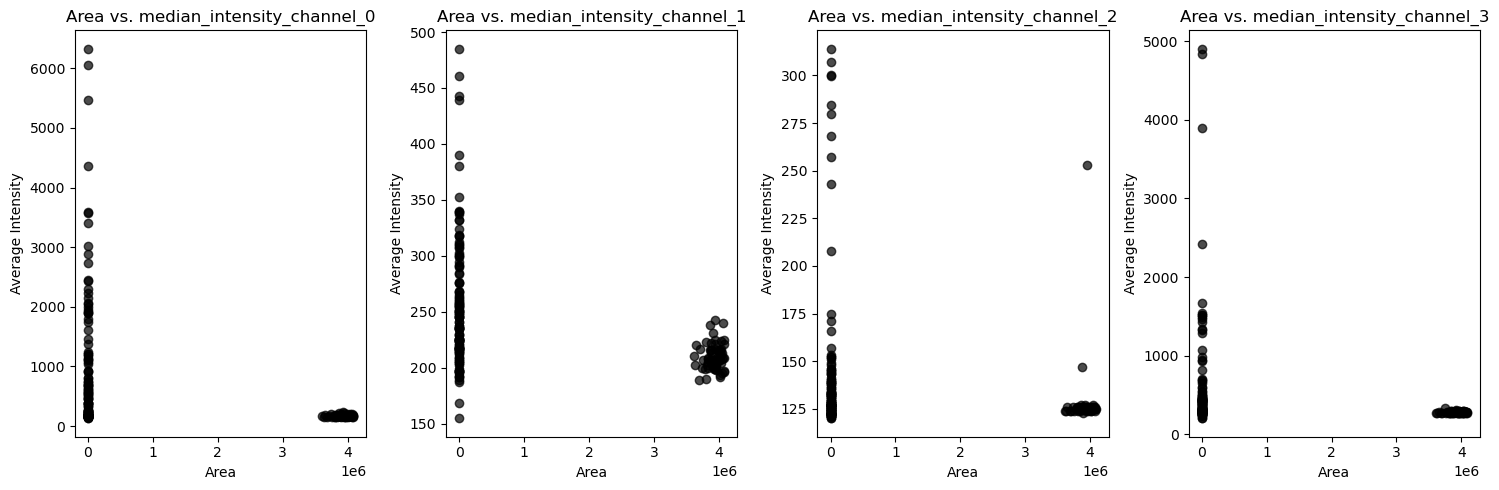

In [9]:
# Determine the number of channels from the DataFrame column names
channel_columns = [col for col in bk_df.columns if 'median_intensity_channel_' in col]
num_channels = len(channel_columns)

# Set up the figure with subplots arranged side by side
fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))  # Adjust total width and height as needed

if num_channels == 1:  # If there's only one channel, make sure 'axes' is iterable
    axes = [axes]

# Plot each channel's intensity against the area
for idx, channel in enumerate(channel_columns):
    ax = axes[idx]
    ax.scatter(bk_df['area'], bk_df[channel], color='black', alpha=0.7)
    ax.set_title(f'Area vs. {channel}')
    ax.set_xlabel('Area')
    ax.set_ylabel('Average Intensity')

# Ensure the layout is organized to prevent overlap of plot elements
plt.tight_layout()
plt.show()

The background objects fall clearly into two categories, one with large objects that have low intensity values (the true background) and one with small objects of varying intensity levels (some as high as the nuclei, the true signal). If we do background subtraction, we should only use the large objects, with low intensity values

In [10]:
# CHUNK 3 (cont) #
# Incorporate the same operations ran above into a single step that extracts the largest background ROI
# and calculates the corresponding intensities

from background_subtraction import get_largest_background

# Initialize a list to store background values
bk_values = []

# Loop over each experiment in the data
for experiment, data in all_experiments_data.items():
    # Use matched indices to correctly process each image and its corresponding mask within the experiment
    for img_index, mask_index in data["matched_indices"]:
        image = data['all_images']['image'][img_index]  # Get the correct image by image index
        mask = data['all_images']['mask_n'][mask_index]  # Get the corresponding mask by mask index

        # Get background data for the current image-mask pair
        result = get_largest_background(mask, image, img_index)
        area = result['area']
        
        # Collect data for each channel from the background analysis
        for channel, (avg_intensity, median_intensity, min_intensity) in enumerate(zip(result['average_intensities'], 
                                                                                       result['median_intensities'], 
                                                                                       result['min_intensities'])):
            bk_values.append({
                'experiment': experiment,  # Add experiment name
                'image_index': img_index,  # Store image index to track which image this data belongs to
                'mask_index': mask_index,  # Also store mask index for completeness
                'channel': channel,
                'avg_intensity': avg_intensity,
                'median_intensity': median_intensity,
                'min_intensity': min_intensity,
                'area': area
            })

# Convert the list of formatted dictionaries to a DataFrame
bk_df = pd.DataFrame(bk_values)
print(bk_df.head())

            experiment  image_index  mask_index  channel  avg_intensity  \
0  03312026_aneuploidy            0          34        0     252.863701   
1  03312026_aneuploidy            0          34        1     201.548090   
2  03312026_aneuploidy            0          34        2     125.447436   
3  03312026_aneuploidy            0          34        3     358.841266   
4  03312026_aneuploidy            1          60        0     491.985768   

   median_intensity  min_intensity     area  
0             162.0            116  3883406  
1             194.0            135  3883406  
2             124.0            107  3883406  
3             287.0            182  3883406  
4             220.0            121  3631572  


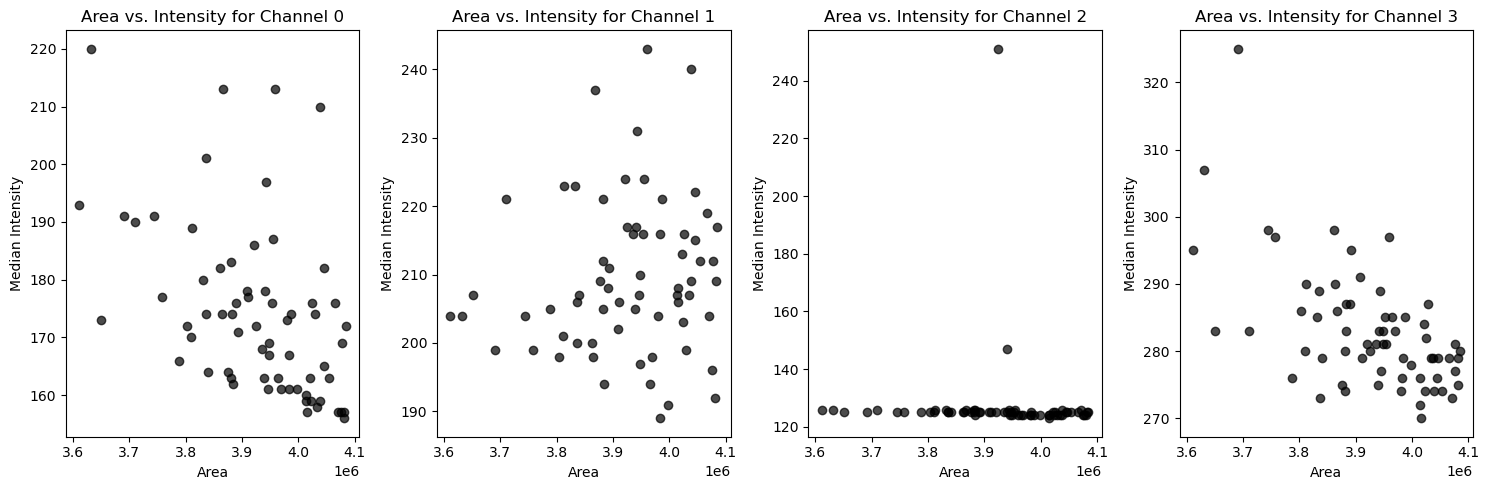

In [11]:
# Plot area vs intensity for each channel for the true background only (optional)

# Determine the number of channels from the DataFrame column names
# Determine the number of channels from the DataFrame by examining the unique values in the 'channel' column
num_channels = bk_df['channel'].max() + 1  # Assuming channel numbers start from 0

# Set up the figure with subplots arranged side by side
fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))  # Adjust total width and height as needed

if num_channels == 1:  # If there's only one channel, make sure 'axes' is iterable
    axes = [axes]

# Plot each channel's intensity against the area
for idx in range(num_channels):
    current_df = bk_df[bk_df['channel'] == idx]
    ax = axes[idx]
    ax.scatter(current_df['area'], current_df['median_intensity'], color='black', alpha=0.7)
    ax.set_title(f'Area vs. Intensity for Channel {idx}')
    ax.set_xlabel('Area')
    ax.set_ylabel('Median Intensity')

# Ensure the layout is organized to prevent overlap of plot elements
plt.tight_layout()
plt.show()

In [12]:
# CHUNK 4 #

# Extract a set of metrics for each ROI in the image-mask pair
# using the measureROIs() function
# Edge trimming is optional — defaults to removing cells within 100px of the image edge

# --- Configure analysis options in one place ---
CONFIG = dict(
    subtract_background = False,
    background_stat     = "min",      # "min" | "median" | "mean"
    remove_edges        = False,
    edge_margin         = 100,
    edge_method         = "centroid", # "centroid" | "bbox"
    # clip_after_subtraction = False,  # include if your measureROIs has this arg
)

# Import function
from get_roi_metrics import measureROIs

# Set up logging for debugging and progress tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Prepare dictionary to store ROI metrics
all_roi_metrics = {}

# Wrapper function for measureROIs() to process each image and mask pair
def process_image_data(task):
    img_index, mask_index, experiment = task
    image = all_experiments_data[experiment]['all_images']['image'][img_index]
    mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
    return experiment, img_index, measureROIs((img_index, image, mask), **CONFIG)

# Execute processing in parallel for each experiment in all_experiments_data
if __name__ == '__main__':
    with ThreadPoolExecutor(max_workers=4) as executor:
        # Create tasks with experiment information based on matched indices in each experiment
        tasks = [(img_index, mask_index, experiment) 
                 for experiment, data in all_experiments_data.items() 
                 for img_index, mask_index in data["matched_indices"]]

        # Process tasks in parallel
        results = list(executor.map(process_image_data, tasks))

        # Store the results in the dictionary
        for result in results:
            experiment, img_index, roi_metrics = result
            # Store metrics by experiment and image index
            if experiment not in all_roi_metrics:
                all_roi_metrics[experiment] = {}
            all_roi_metrics[experiment][f'Image {img_index}'] = roi_metrics

    # --- Compose a detailed final message from CONFIG ---
    bg_msg = ("enabled"
              f" (stat={CONFIG.get('background_stat','min')})"
              if CONFIG.get('subtract_background', False) else "disabled")

    if CONFIG.get('remove_edges', False):
        edge_msg = (f"enabled (method={CONFIG.get('edge_method','centroid')}, "
                    f"margin={CONFIG.get('edge_margin', 0)} px)")
    else:
        edge_msg = "disabled"

    logging.info(
        "Metrics extraction complete for all ROIs across all matched images. "
        f"Background subtraction: {bg_msg}. Edge trimming: {edge_msg}."
    )

2026-04-08 15:04:34,211 - INFO - Metrics extraction complete for all ROIs across all matched images. Background subtraction: disabled. Edge trimming: disabled.


In [13]:
# CHUNK 4.2 #

# Do the same as above, but doing background subtraction — 
# remove background min as default stat, but "mean" and "median" are also options
# Edge trimming is optional — defaults to removing cells within 100px of the image edge using centroid. Bounding-box method also optional

# --- Configure analysis options in one place ---
CONFIG = dict(
    subtract_background = True,
    background_stat     = "min",      # "min" | "median" | "mean"
    remove_edges        = False,
    edge_margin         = 100,
    edge_method         = "centroid", # "centroid" | "bbox"
    # clip_after_subtraction = False,  # include if your measureROIs has this arg
)

# Import function
from get_roi_metrics import measureROIs

# Set up logging for debugging and progress tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Prepare dictionary to store ROI metrics
bs_roi_metrics = {}

# Wrapper function for measureROIs() to process each image and mask pair
def process_image_data(task):
    img_index, mask_index, experiment = task
    image = all_experiments_data[experiment]['all_images']['image'][img_index]
    mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
    return experiment, img_index, measureROIs((img_index, image, mask), **CONFIG)

# Execute processing in parallel for each experiment in all_experiments_data
if __name__ == '__main__':
    with ThreadPoolExecutor(max_workers=4) as executor:
        # Create tasks with experiment information based on matched indices in each experiment
        tasks = [(img_index, mask_index, experiment) 
                 for experiment, data in all_experiments_data.items() 
                 for img_index, mask_index in data["matched_indices"]]

        # Process tasks in parallel
        results = list(executor.map(process_image_data, tasks))

        # Store the results in the dictionary
        for result in results:
            experiment, img_index, roi_metrics = result
            # Store metrics by experiment and image index
            if experiment not in bs_roi_metrics:
                bs_roi_metrics[experiment] = {}
            bs_roi_metrics[experiment][f'Image {img_index}'] = roi_metrics
            
    # --- Compose a detailed final message from CONFIG ---
    bg_msg = ("enabled"
              f" (stat={CONFIG.get('background_stat','min')})"
              if CONFIG.get('subtract_background', False) else "disabled")

    if CONFIG.get('remove_edges', False):
        edge_msg = (f"enabled (method={CONFIG.get('edge_method','centroid')}, "
                    f"margin={CONFIG.get('edge_margin', 0)} px)")
    else:
        edge_msg = "disabled"

    logging.info(
        "Metrics extraction complete for all ROIs across all matched images. "
        f"Background subtraction: {bg_msg}. Edge trimming: {edge_msg}."
    )

2026-04-08 15:04:43,262 - INFO - Metrics extraction complete for all ROIs across all matched images. Background subtraction: enabled (stat=min). Edge trimming: disabled.


In [14]:
# CHUNK 5 #

# Turn the all_roi_metrics and the bs_roi_metrics dictionaries into Pandas data frames for easier manipulation

# List to hold each row's data
data_rows = []

# Iterate through each level of the nested dictionary to extract data
# for each channel of each ROI in each image
for experiment, images in all_roi_metrics.items():
    for image_key, rois in images.items():
        image_index = int(image_key.split()[1])  # Extract image index
        file_name = all_experiments_data[experiment]['base_names']['image'][image_index]  # Get the file name from base names
        
        # Unpack rois tuple into roi_key and channels dictionary
        roi_key, channels_dict = rois  # Unpacking the tuple

        for roi_key, channels in channels_dict.items():  # Using roi_key instead of region_label
            for channel_label, metrics in channels.items():
                # Create a dictionary for each row of data 
                # including experiment, image, ROI, channel, and metrics
                row_data = {
                    "experiment": experiment,
                    "image_index": image_index,
                    "filename": file_name,
                    "ROI_index": roi_key,  # Use roi_key as the unique identifier for each ROI
                    "channel": int(channel_label.split()[1])  # Convert 'Channel X' to integer X
                }

                # Add each metric in metrics to row_data
                for metric_name, metric_value in metrics.items():
                    row_data[metric_name] = metric_value

                # Append each row_data dictionary to the data_rows list
                data_rows.append(row_data)

# Convert the list of dictionaries to a DataFrame
metrics_df = pd.DataFrame(data_rows)

# List to hold each row's data
data_rows = []

# Iterate through each level of the nested dictionary to extract data
# for each channel of each ROI in each image
for experiment, images in bs_roi_metrics.items():
    for image_key, rois in images.items():
        image_index = int(image_key.split()[1])  # Extract image index
        file_name = all_experiments_data[experiment]['base_names']['image'][image_index]  # Get the file name from base names
        
        # Unpack rois tuple into roi_key and channels dictionary
        roi_key, channels_dict = rois  # Unpacking the tuple

        for roi_key, channels in channels_dict.items():  # Using roi_key instead of region_label
            for channel_label, metrics in channels.items():
                # Create a dictionary for each row of data 
                # including experiment, image, ROI, channel, and metrics
                row_data = {
                    "experiment": experiment,
                    "image_index": image_index,
                    "filename": file_name,
                    "ROI_index": roi_key,  # Use roi_key as the unique identifier for each ROI
                    "channel": int(channel_label.split()[1])  # Convert 'Channel X' to integer X
                }

                # Add each metric in metrics to row_data
                for metric_name, metric_value in metrics.items():
                    row_data[metric_name] = metric_value

                # Append each row_data dictionary to the data_rows list
                data_rows.append(row_data)

# Convert the list of dictionaries to a DataFrame
metricsBS_df = pd.DataFrame(data_rows)

In [17]:
# Optional: Display the first few rows of the DataFrame to verify it's correct
print(metricsBS_df.head())

#print(metrics_df['channel'].unique())

               experiment  image_index  \
0  03062026_ZF-multicolor            0   
1  03062026_ZF-multicolor            0   
2  03062026_ZF-multicolor            0   
3  03062026_ZF-multicolor            0   
4  03062026_ZF-multicolor            0   

                                           filename  ROI_index  channel  area  \
0  06032026_ZF-multicolor_group2_1_MMStack_Pos6_MIP          1        0  4201   
1  06032026_ZF-multicolor_group2_1_MMStack_Pos6_MIP          1        1  4201   
2  06032026_ZF-multicolor_group2_1_MMStack_Pos6_MIP          1        2  4201   
3  06032026_ZF-multicolor_group2_1_MMStack_Pos6_MIP          1        3  4201   
4  06032026_ZF-multicolor_group2_1_MMStack_Pos6_MIP          2        0  2515   

          avg  median         std  maxima  minima  
0  304.516068   304.0   26.749151   409.0   225.0  
1   58.530112    58.0    8.843268    96.0    32.0  
2   19.981909    20.0    4.001268    37.0     3.0  
3  155.374911   154.0   21.935074   248.0    90.0  


In [ ]:
print(bk_df.head())

In [15]:
# FILE SAVING #

# Save data frame with background metrics (bk_df) to the "results" folder
# in the analysis repository

# Files for each experiment will be saved in their own folder as .csv files
# They can subsequently be read in and joined as needed
# This is more versatile than combining data from multiple experiments into a single big .csv file

# Create the path to the results folder
results_dir = os.path.join(repo_directory, "results")

# Get today's date string to use as a suffix
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Incorporate the file name (as "base_name" for consistency) into bk_df
# and remove "mask_index" for simplicity, since the background data corresponds to the images anyway
bk_export = pd.merge(bk_df, 
                metricsBS_df[['experiment', 'image_index', 'filename']].drop_duplicates(),
                on = ['experiment', 'image_index'], how = 'left')
bk_export.rename(columns={"filename": "base_name"}, inplace=True)
del bk_export['mask_index']

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    experiment_folder = os.path.join(results_dir, experiment)
    
    # Create the folder if it doesn't already exist
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the DataFrames for the current experiment.
    # (Assumes your bk_df data frame includes an "experiment" column.)
    bk_export_exp = bk_export[bk_export['experiment'] == experiment]
    
    # Define the default file path for the CSV files
    bk_df_file = os.path.join(experiment_folder, "background_metrics.csv")
    
    # If the background_metrics file already exists, add the date suffix to create a new filename.
    if os.path.exists(bk_df_file):
        bk_df_file = os.path.join(experiment_folder, f"background_metrics_{date_suffix}.csv")
    
    # Save the DataFrames to their respective CSV files
    bk_export_exp.to_csv(bk_df_file, index=False)

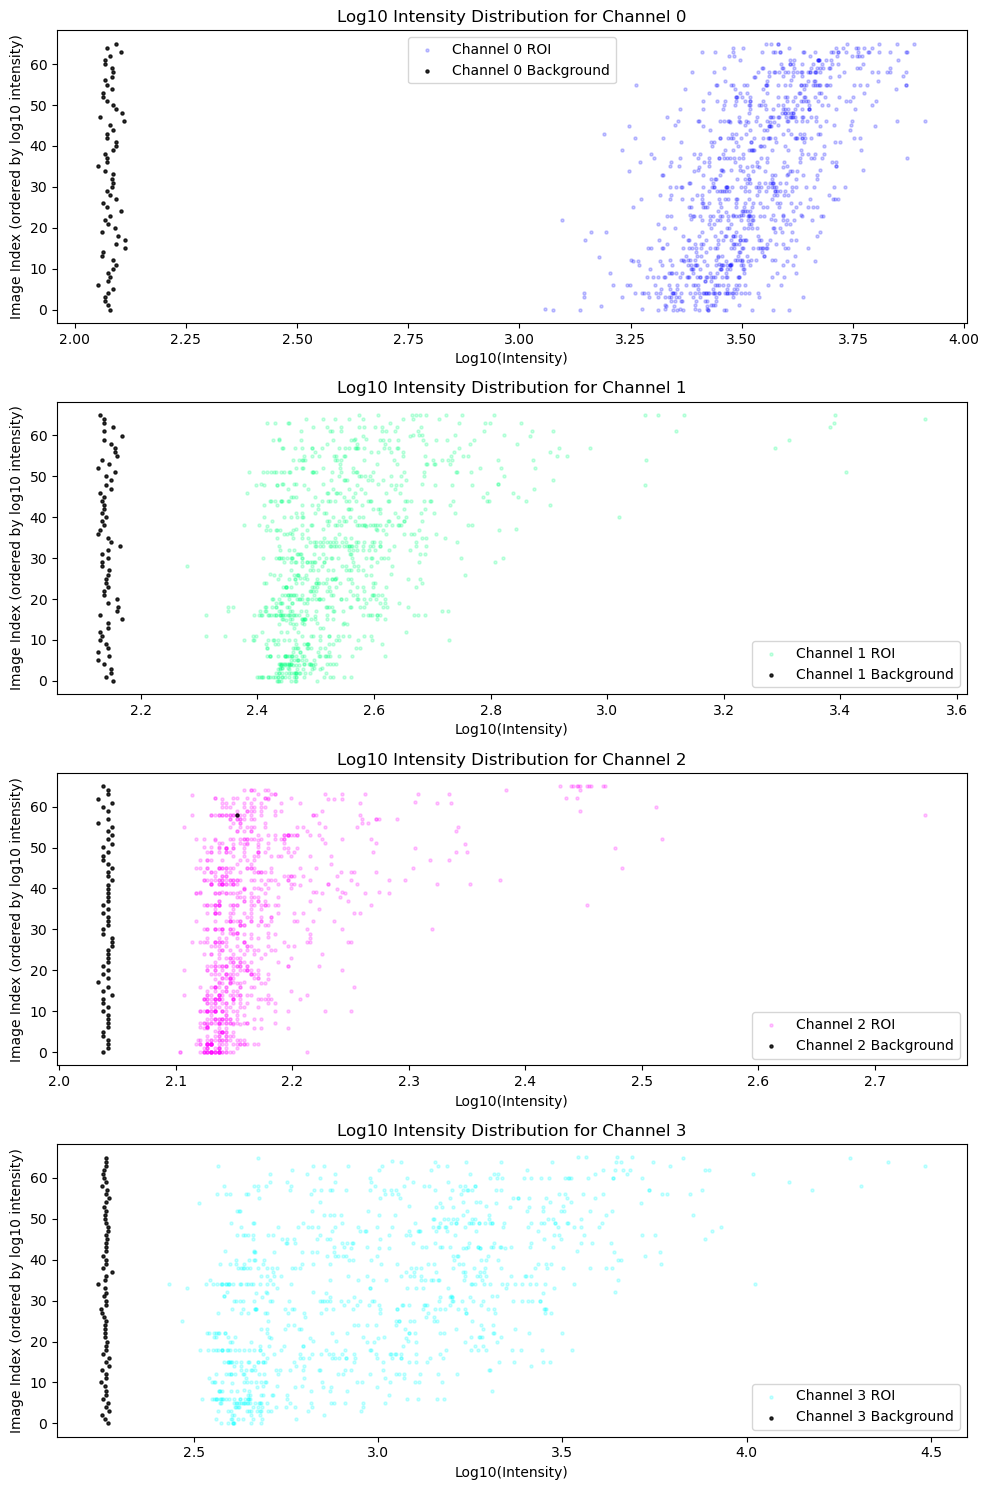

In [16]:
# Plot the background values over the nuclear values to assess if they are in the expected range:

# Define the colors for each channel
# channel_colors = {0: 'cyan', 1: 'springgreen', 2: 'magenta'}
channel_colors = {0: 'blue', 1: 'springgreen', 2: 'magenta', 3: 'cyan'}

# Define the number of channels to plot data for
nc = metrics_df['channel'].nunique()

# Setup the figure
fig, ax = plt.subplots(nc, 1, figsize=(10, 15))  # Wide plot

def add_jitter(values, jitter_strength=0.03):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(values))
    return values + jitter

# Plot data for each channel
for channel, ax in enumerate(ax):
    # Get data for the current channel
    roi_data = metrics_df[metrics_df['channel'] == channel]
    bk_data = bk_df[bk_df['channel'] == channel]

    # Calculate log10 intensities
    roi_log10_data = np.log10(roi_data['median'] + 1)  # Log10 transform
    bk_log10_data = np.log10(bk_data['min_intensity'] + 1)

    # Calculate mean log10 intensity per image index for sorting
    median_log10_intensity_per_image = roi_data.groupby('image_index')['median'].mean()
    sorted_indices = median_log10_intensity_per_image.sort_values().index

    # Map sorted indices to new ordered indices
    roi_data = roi_data.copy()  # Avoids setting with copy warning
    bk_data = bk_data.copy()    # Avoids setting with copy warning
    roi_data.loc[:, 'ordered_index'] = roi_data['image_index'].map({idx: i for i, idx in enumerate(sorted_indices)})
    bk_data.loc[:, 'ordered_index'] = bk_data['mask_index'].map({idx: i for i, idx in enumerate(sorted_indices)})

    # Add jitter for better visibility in scatter plot
    roi_image_indices = add_jitter(roi_data['ordered_index'])
    bk_image_indices = add_jitter(bk_data['ordered_index'])

    # Scatter plots
    # Plot ROI data
    ax.scatter(roi_log10_data, roi_image_indices, 
               color=channel_colors[channel], 
               s=5,
               alpha=0.2, 
               label=f'Channel {channel} ROI')
    # Plot Background data
    ax.scatter(bk_log10_data, bk_image_indices, 
               color='black', 
               s=5,
               alpha=0.8, 
               label=f'Channel {channel} Background')

    # Set titles and labels
    ax.set_title(f'Log10 Intensity Distribution for Channel {channel}')
    ax.set_xlabel('Log10(Intensity)')
    ax.set_ylabel('Image Index (ordered by log10 intensity)')
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

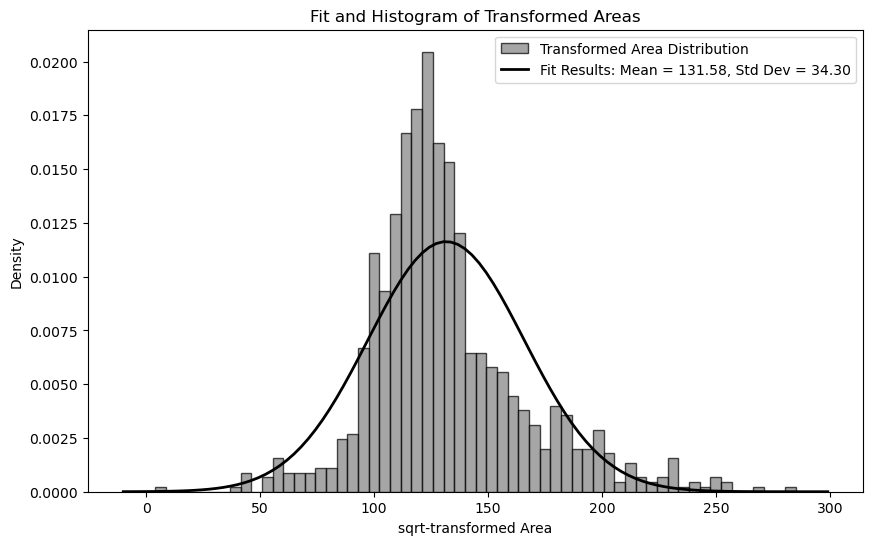

In [17]:
# Plot the distribution of ROI areas in the raw data
# and save to the "plots" folder in the repository directory

# Set the transformation (log or sqrt) of the data you want to visualize
tx = 'sqrt'

# Define the directory to save the plot
if len(experiment_list) > 1:
    experiment_name = experiment_list[0] + "-" + experiment_list[-1]
else:
    experiment_name = experiment_list[0]
    
plot_dir = os.path.join(repo_directory, "plots", experiment_name)
os.makedirs(plot_dir, exist_ok = True)

# Collect all ROI areas directly from the DataFrame
all_areas = metricsBS_df['area'].values

# Apply the transformation (log or sqrt)
if tx == 'log':
    tx_areas = np.log(all_areas + 1)  # Added 1 to avoid log(0)
elif tx == 'sqrt':
    tx_areas = np.sqrt(all_areas)
else:
    raise ValueError("Transformation should be either 'log' or 'sqrt'.")

# Fit a normal distribution to the transformed areas
mean, std_dev = norm.fit(tx_areas)

# Generate histogram of the transformed areas
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(tx_areas, 
                            bins=60, 
                            color='gray', 
                            edgecolor='black', 
                            linewidth=1, 
                            alpha=0.7, 
                            label='Transformed Area Distribution', 
                            density=True)
plt.xlabel(f'{tx}-transformed Area')
plt.ylabel('Density')

# Generate the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.title('Fit and Histogram of Transformed Areas')
plt.legend()

# Save the plot to disk as a .png file
plot_filename = 'area_distr_original.png'  # Replace with your desired file name
plt.savefig(f"{plot_dir}/{plot_filename}", format='png')  # Change format to 'tif' if needed

# Show the plot on the console
plt.show()

plt.close()  # Close the plot to free memory

In [18]:
# CHUNK 6 # 

# Remove values outside the number of SD that the user defines 
# for the log or sqrt-transformed data, as above
# (2*SD seems generally reasonable for this data)
# using the outliersOut function found in outliers_removal.py

from outliers_removal import outliersOut

sd_cutoff = 1
tx = "sqrt"

filtr_metrics_df, thresholds = outliersOut(metrics_df, sd_filter = sd_cutoff, transformation = tx)
filtr_metricsBS_df, thresholds = outliersOut(metricsBS_df, sd_filter = sd_cutoff, transformation = tx)

# Print the thresholds to verify them
print("Calculated thresholds:")
print(f"Mean: {thresholds[0]}, Std Dev: {thresholds[1]}")
print(f"Lower Threshold: {thresholds[2]}, Upper Threshold: {thresholds[3]}")

# Optionally, display some of the filtered data to inspect the results
# print(filtr_metrics_df.head())

Calculated thresholds:
Mean: 131.58035136218723, Std Dev: 34.30017143402283
Lower Threshold: 97.2801799281644, Upper Threshold: 165.88052279621007


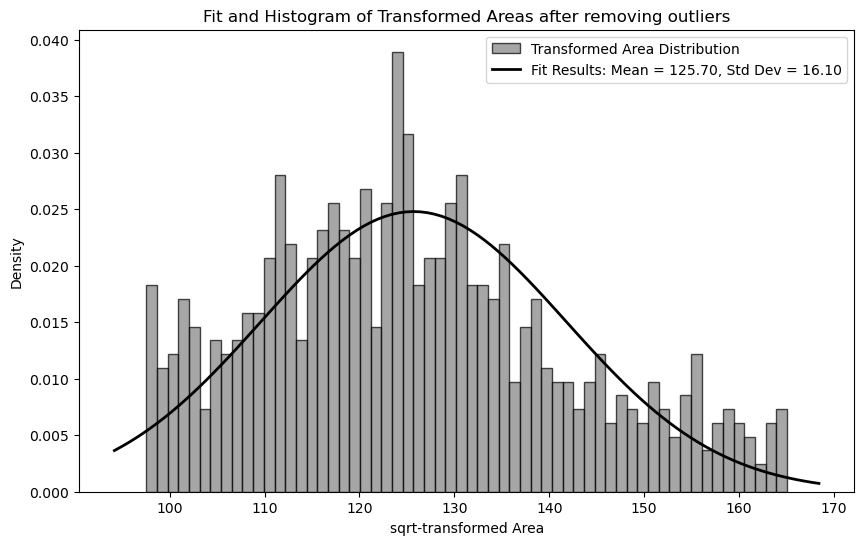

In [19]:
# Plot the distribution of ROI areas in the filtered data
# and save to the "plots" folder in the repository directory

# Set the transformation (log or sqrt) of the data you want to visualize
tx = 'sqrt'

# Collect all ROI areas directly from the DataFrame
all_areas = filtr_metricsBS_df['area'].values

# Apply the transformation (log or sqrt)
if tx == 'log':
    tx_areas = np.log(all_areas + 1)  # Added 1 to avoid log(0)
elif tx == 'sqrt':
    tx_areas = np.sqrt(all_areas)
else:
    raise ValueError("Transformation should be either 'log' or 'sqrt'.")

# Fit a normal distribution to the transformed areas
mean, std_dev = norm.fit(tx_areas)

# Generate histogram of the transformed areas
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(tx_areas, 
                            bins=60, 
                            color='gray', 
                            edgecolor='black', 
                            linewidth=1, 
                            alpha=0.7, 
                            label='Transformed Area Distribution', 
                            density=True)
plt.xlabel(f'{tx}-transformed Area')
plt.ylabel('Density')

# Generate the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.title('Fit and Histogram of Transformed Areas after removing outliers')
plt.legend()

# Save the plot to disk as a .png file
plot_filename = 'area_distr_no-outliers.png'  # Replace with your desired file name
plt.savefig(f"{plot_dir}/{plot_filename}", format='png')  # Change format to 'tif' if needed

# Show the plot on the console
plt.show()

plt.close()  # Close the plot to free memory

In [ ]:
print(filtr_metricsBS_df.head())

In [20]:
# Read in the experimental-groups reference files

# Initialize an empty list to store each experiments data frame
exp_groups_list = []

# Loop through each experiment defined at the beginning and read its CSV file
for experiment in experiment_list:
    # Read the CSV file for the current experiment
    exp_group_df = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))
    
    # Rename the column "experiment_folder" to "experiment"
    exp_group_df.rename(columns={"experiment_folder": "experiment"}, inplace=True)
    
    # Append the DataFrame to the list
    exp_groups_list.append(exp_group_df)

# Combine all DataFrames in the list into a single DataFrame
exp_groups = pd.concat(exp_groups_list, ignore_index=True)

In [21]:
# CHUNK 7
# Combine the metrics_df data frame with the metadata contained in exp_groups, 
# so that we can group observations by experiment

# First, modify filename in exp_groups so that it matches that of metrics_df
# (instead of ending in ".ome.tif", it must end in "_MIP.tif")
exp_groups['filename'] = exp_groups['filename'].str.replace('.ome.tif', '_MIP')

# Then, combine both data frames with a left join using Pandas' merge() function
# and rename the filename columns to base_name, for consistency across data frames
combined_df = pd.merge(filtr_metrics_df, exp_groups, on = ["filename", "experiment"], how = "inner")
combined_df.rename(columns={"filename": "base_name"}, inplace=True)
combinedBS_df = pd.merge(filtr_metricsBS_df, exp_groups, on = ["filename", "experiment"], how = "inner")
combinedBS_df.rename(columns={"filename": "base_name"}, inplace=True)

In [22]:
# Do a quick QC of data frames pre-and post-merge, to ensure no rows were lost in the process

# Look at unique entries in both
unique_metrics_filenames = filtr_metrics_df['filename'].nunique()
print(f"Number of unique filenames in metrics_df: {unique_metrics_filenames}")
unique_combined_filenames = combined_df['base_name'].nunique()
print(f"Number of unique filenames in combined_df: {unique_combined_filenames}")
unique_combinedBS_filenames = combinedBS_df['base_name'].nunique()
print(f"Number of unique filenames in combinedBS_df: {unique_combinedBS_filenames}")

# Total number of entries:
print(f"Total entries in metrics_df: {filtr_metrics_df.shape[0]}")
print(f"Total entries in combined_df: {combined_df.shape[0]}")
print(f"Total entries in combinedBS_df: {combinedBS_df.shape[0]}")

# And unique instances of "plasmid"
unique_plasmids = exp_groups['plasmid'].nunique()
unique_combined_plasmids = combined_df['plasmid'].nunique()
unique_combinedBS_plasmids = combinedBS_df['plasmid'].nunique()
print(f"Unique plasmids in experiment: {unique_plasmids}")
print(f"Unique plasmids in combined_df: {unique_combined_plasmids}")
print(f"Unique plasmids in combinedBS_df: {unique_combinedBS_plasmids}")

Number of unique filenames in metrics_df: 65
Number of unique filenames in combined_df: 65
Number of unique filenames in combinedBS_df: 65
Total entries in metrics_df: 2924
Total entries in combined_df: 2924
Total entries in combinedBS_df: 2924
Unique plasmids in experiment: 1
Unique plasmids in combined_df: 1
Unique plasmids in combinedBS_df: 1


In [ ]:
print(combinedBS_df.head())

In [36]:
# FILE SAVING #

# Save the combined_df and combinedBS_df to disc as the cell metrics dataset 

# Files for each experiment will be saved in their own folder as .csv files
# This approach makes it easy to import them into other notebooks and combine them again if needed

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Get today's date string to use as a suffix if older versions of the file are present
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    # and create it if not already present
    experiment_folder = os.path.join(results_dir, experiment)
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the DataFrames for the current experiment 
    # (Assumes your combined_df and combinedBS_df data frames include an "experiment" column.)
    # and remove the "tx_area" column that was created during outlier size filtering
    combined_df_exp = combined_df[combined_df['experiment'] == experiment]
    del combined_df_exp['tx_area']
    combinedBS_df_exp = combinedBS_df[combinedBS_df['experiment'] == experiment]
    del combinedBS_df_exp['tx_area']
    
    # Define the default file paths for the CSV files
    noBS_file = os.path.join(experiment_folder, "cell_metrics_noBS.csv")
    siBS_file = os.path.join(experiment_folder, "cell_metrics_postBS.csv")
    
    # If the raw (no BS) file already exists, add the date suffix to create a new filename
    if os.path.exists(noBS_file):
        noBS_file = os.path.join(experiment_folder, f"cell_metrics_noBS_{date_suffix}.csv")
    
    # If the background-subtracted (postBS) file already exists, add the date suffix to create a new filename
    if os.path.exists(siBS_file):
        siBS_file = os.path.join(experiment_folder, f"cell_metrics_postBS_{date_suffix}.csv")
    
    # Save the DataFrames to their respective CSV files
    combined_df_exp.to_csv(noBS_file, index=False)
    combinedBS_df_exp.to_csv(siBS_file, index=False)

# Cell classification
After reading files, finding nuclei, performing background subtraction and removing outliers by size, it's time to classify cells. 

The code below is focused on separating transfected from untransfected cells based on fluorescent (mostly GFP) signal, but it's trivial to adapt it to classify cells based on other FPs or whatever is needed.

In [23]:
# Read plasmid reference file
#plasmid_ref_file = 'plasmid_ref_hCECs.csv'
plasmid_ref_file = 'plasmid_ref_pb-ZFs.csv'

plasmid_ref = pd.read_csv(os.path.join(repo_directory, 'reference/', plasmid_ref_file))
#print(plasmid_ref['plasmid'].unique())
print(plasmid_ref.head())

                       plasmid promoter        fusion      probe   NLS polyA
0                         none     none          none       none  none  none
1             NT-GFP_Cen7-ZF1g     pCMV        NT-GFP  Cen7-ZF1g  SV40   bGH
2          pb_NT-GFP_Cen7-ZF1g    pEF1a        NT-GFP  Cen7-ZF1g  SV40   bGH
3  NT-ABI1_Cen7-ZF1g_mStayGold     pCMV  CT-mStayGold  Cen7-ZF1g  SV40   bGH
4          pb_mSG_Cen7-ZF1g_v2    pEF1a  NT-mStayGold  Cen7-ZF1g  none   bGH


In [24]:
# Incorporate plasmid information into combined_df
# filtering for plasmids contained in the plasmid_ref data frame only
# MAKE SURE your names match so you don't drop data
#combinedBS_df.rename(columns = {"test_plasmid": "plasmid"}, inplace = True)
combinedBS_df = pd.merge(plasmid_ref[['plasmid', 'promoter', 'fusion', 'probe', 
                                     #'cargo', 'fusion2','dimerization'
                                     ]], 
                         combinedBS_df, 
                         on = "plasmid", how = "right")
#print(combined_df.head())

In [30]:
print(combinedBS_df['plasmid'].unique())

['pb_mSG_Cen14-ZF4b_v2_SV40pA' 'pb_mSG_Cen14-ZF2a_v2_SV40pA'
 'pb_mSG_Cen1-ZF1c_v2_SV40pA' 'none' 'pb_mSG_Cen7-ZF1f_v2_SV40pA']


In [25]:
# Prepare to plot the data obtained above using plotnine

# Choose the metric to plot:
my_metric = 'median'
x_label = "Median Intensity"

# Calculate the log10 of the chosen metric
combinedBS_df['log10_median'] = np.log10(combinedBS_df[my_metric] + 1)  # Adding 1 to avoid log(0)

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/themes/themeable.py:2438: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


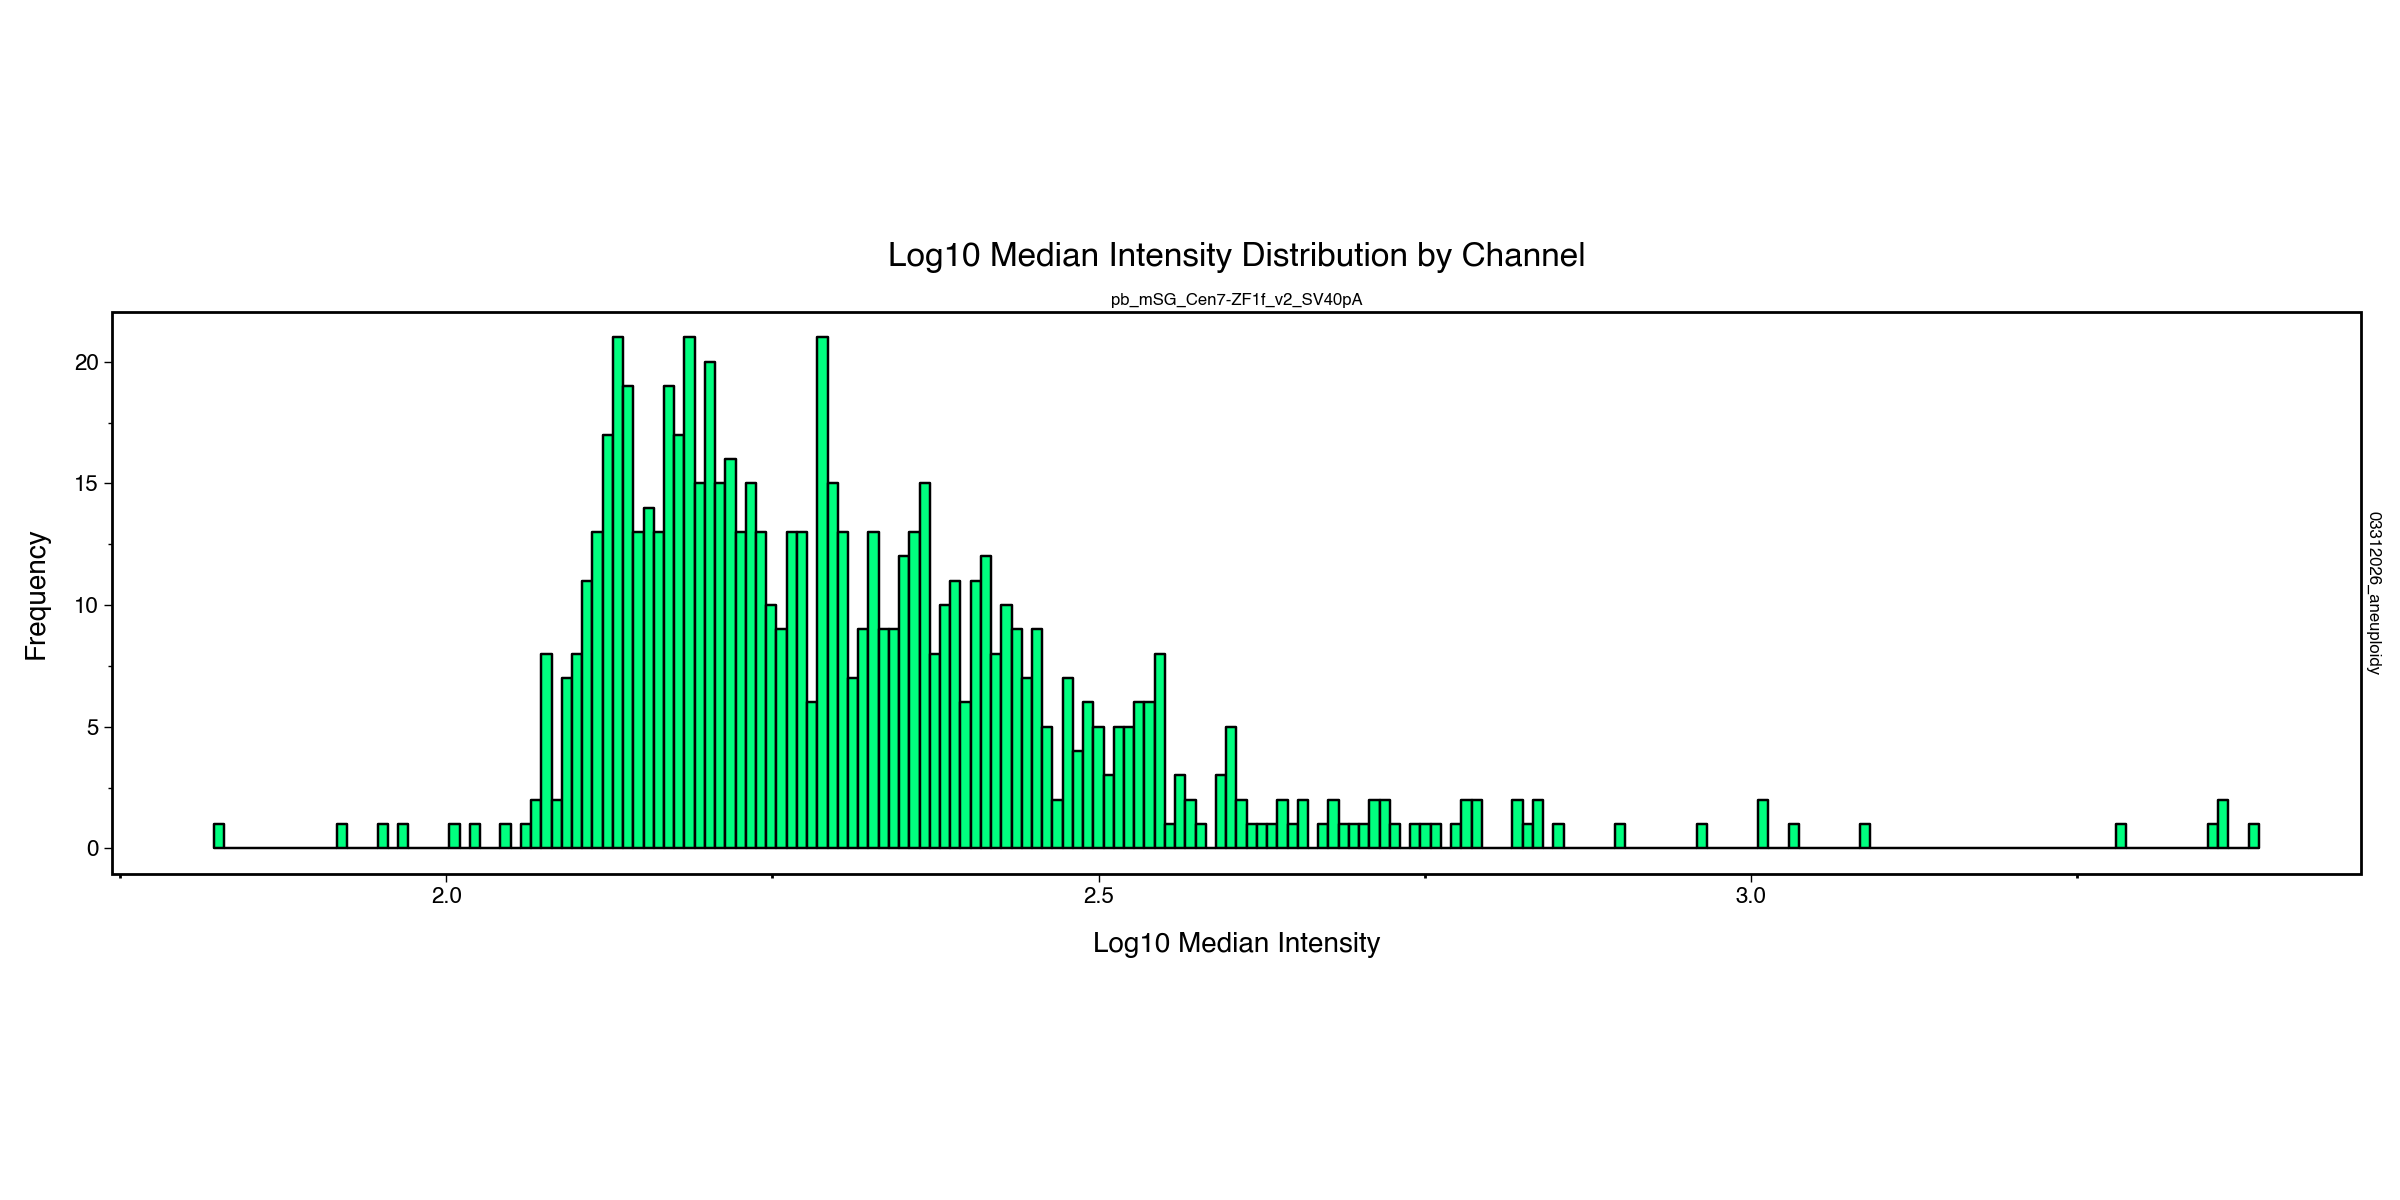

In [26]:
# Make exploratory histograms

# Plot the values of Channel 0 (Hoechst) and Channel 1 (GFP) as histograms for each plasmid

# Assign colors to each channel
channel_colors = {0: 'blue', 1: 'springgreen', 2: 'magenta', 3: 'cyan'}

# Define some list of values to filter by
my_plasmids = []
my_experiments = []

# Subset the data to plot if desired
#my_data = combined_df[(combined_df['plasmid'].isin(my_plasmids)) & (combined_df['experiment'].isin(my_experiments))]
my_data = combinedBS_df[combinedBS_df['channel'] == 1]

# Define plot using plotnine
plot = (
    p9.ggplot(data = my_data) + 
    p9.aes(x = 'log10_median', fill = 'factor(channel)') +  # factor() to treat channel as categorical
    p9.geom_histogram(bins = 200, color = 'black') +
    p9.facet_grid('experiment ~ plasmid', scales = 'free_y') +  # Create separate plots for each channel
    #p9.scale_x_continuous(limits = (combined_df['log10_median'].min(), 
    #                                combined_df['log10_median'].max())) +
    p9.scale_fill_manual(values = channel_colors) +
    p9.labs(title = 'Log10 Median Intensity Distribution by Channel',
            x = 'Log10 Median Intensity',
            y = 'Frequency') +
    p9.theme_bw() + 
    p9.theme(figure_size = (12, 6), # Adjust figure size
             aspect_ratio = 1/4,
             subplots_adjust = {'wspace': 0.20},  # Adjust space between plots
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Print the plot
plot

In [ ]:
# Plot the same data as above but as boxplots and scatterplots

# Assign colors to each channel
channel_colors = {0: 'blue', 1: 'springgreen', 2: 'magenta', 3: 'cyan'}

# Define some list of values to filter by
my_plasmids = []
my_experiments = []

# Subset the data to plot if desired
#my_data = combined_df[(combined_df['plasmid'].isin(my_plasmids)) & (combined_df['experiment'].isin(my_experiments))]
my_data = combinedBS_df[(combinedBS_df['channel'] == 1)]

# Define plot using plotnine
plot = (
    p9.ggplot(data = my_data) + 
    p9.aes(x = 'plasmid', y = 'log10_median', color = 'factor(channel)') +  # factor() to treat channel as categorical
    p9.geom_jitter(size = 0.5, alpha = 0.5) +
    p9.scale_color_manual(values = channel_colors) +
    p9.labs(title = 'Log10 Median Intensity Distribution by Channel',
            x = 'Log10 Median Intensity',
            y = 'Frequency') +
    p9.facet_wrap(' ~ experiment', scales = "free_x") +
    p9.theme_bw() + 
    p9.theme(figure_size = (12, 6), # Adjust figure size
             aspect_ratio = 1/2,
             subplots_adjust = {'wspace': 0.4},  # Adjust space between plots
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text_y = p9.element_text(size = 8, color = 'black'), 
             axis_text_x = p9.element_text(size = 6, color = 'black', angle = 45, hjust = 1),
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Print the plot
plot

In [28]:
# Pivot the combined data frame to wide format, separating each channel into one variable, 
# to plot as scatterplot

# Extract a subset of columns into a new data frame
wide_df = combinedBS_df[['image_index', 'base_name', 'plasmid', 
                         'plasmid2', 'plasmid3',
                         #'cargo', 'fusion2','dimerization',
                         #'Dox', 'GFP', 'group',
                         #'genotype', 'cell_line', 'timepoint',
                         #'group', 'MOI',
                         'promoter', 'fusion', 'probe', 
                         'experiment', 'ROI_index', 'channel', 'log10_median']]
#wide_df = combinedBS_df[['image_index', 'base_name', 'treatment', 'label', 'cell_cycle', 
#                       'experiment', 'ROI_index', 'channel', 'log10_median']]

group_indices = ['image_index', 'base_name', 'experiment', 'plasmid',
                 'plasmid2', 'plasmid3',
                 #'Dox', 'GFP', 'group',
                 #'genotype', 'cell_line', 'timepoint',
                 #'group', 'MOI',
                 'promoter', 'fusion', 'probe', 
                 #'cargo', 'fusion2','dimerization',
                 'ROI_index']
#group_indices = ['image_index', 'base_name', 'treatment', 'label', 'experiment',
#             'cell_cycle', 'ROI_index']

# Pivot wide_df to get separate columns for each channel's log10_median
wide_df = wide_df.pivot(
    index = group_indices,  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'log10_median'  # Values to fill with
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_df.columns = [f"{col}_log10_median" if isinstance(col, int) else col for col in wide_df.columns]
wide_df.rename(columns = {
    '0_log10_median': 'ch0_log10_median',
    '1_log10_median': 'ch1_log10_median', 
    '2_log10_median': 'ch2_log10_median', 
    '3_log10_median': 'ch3_log10_median'
}, inplace = True)

In [99]:
print(wide_df.head())

['image_index',
 'base_name',
 'experiment',
 'plasmid',
 'plasmid2',
 'plasmid3',
 'promoter',
 'fusion',
 'probe',
 'ROI_index',
 'ch0_log10_median',
 'ch1_log10_median',
 'ch2_log10_median',
 'ch3_log10_median']

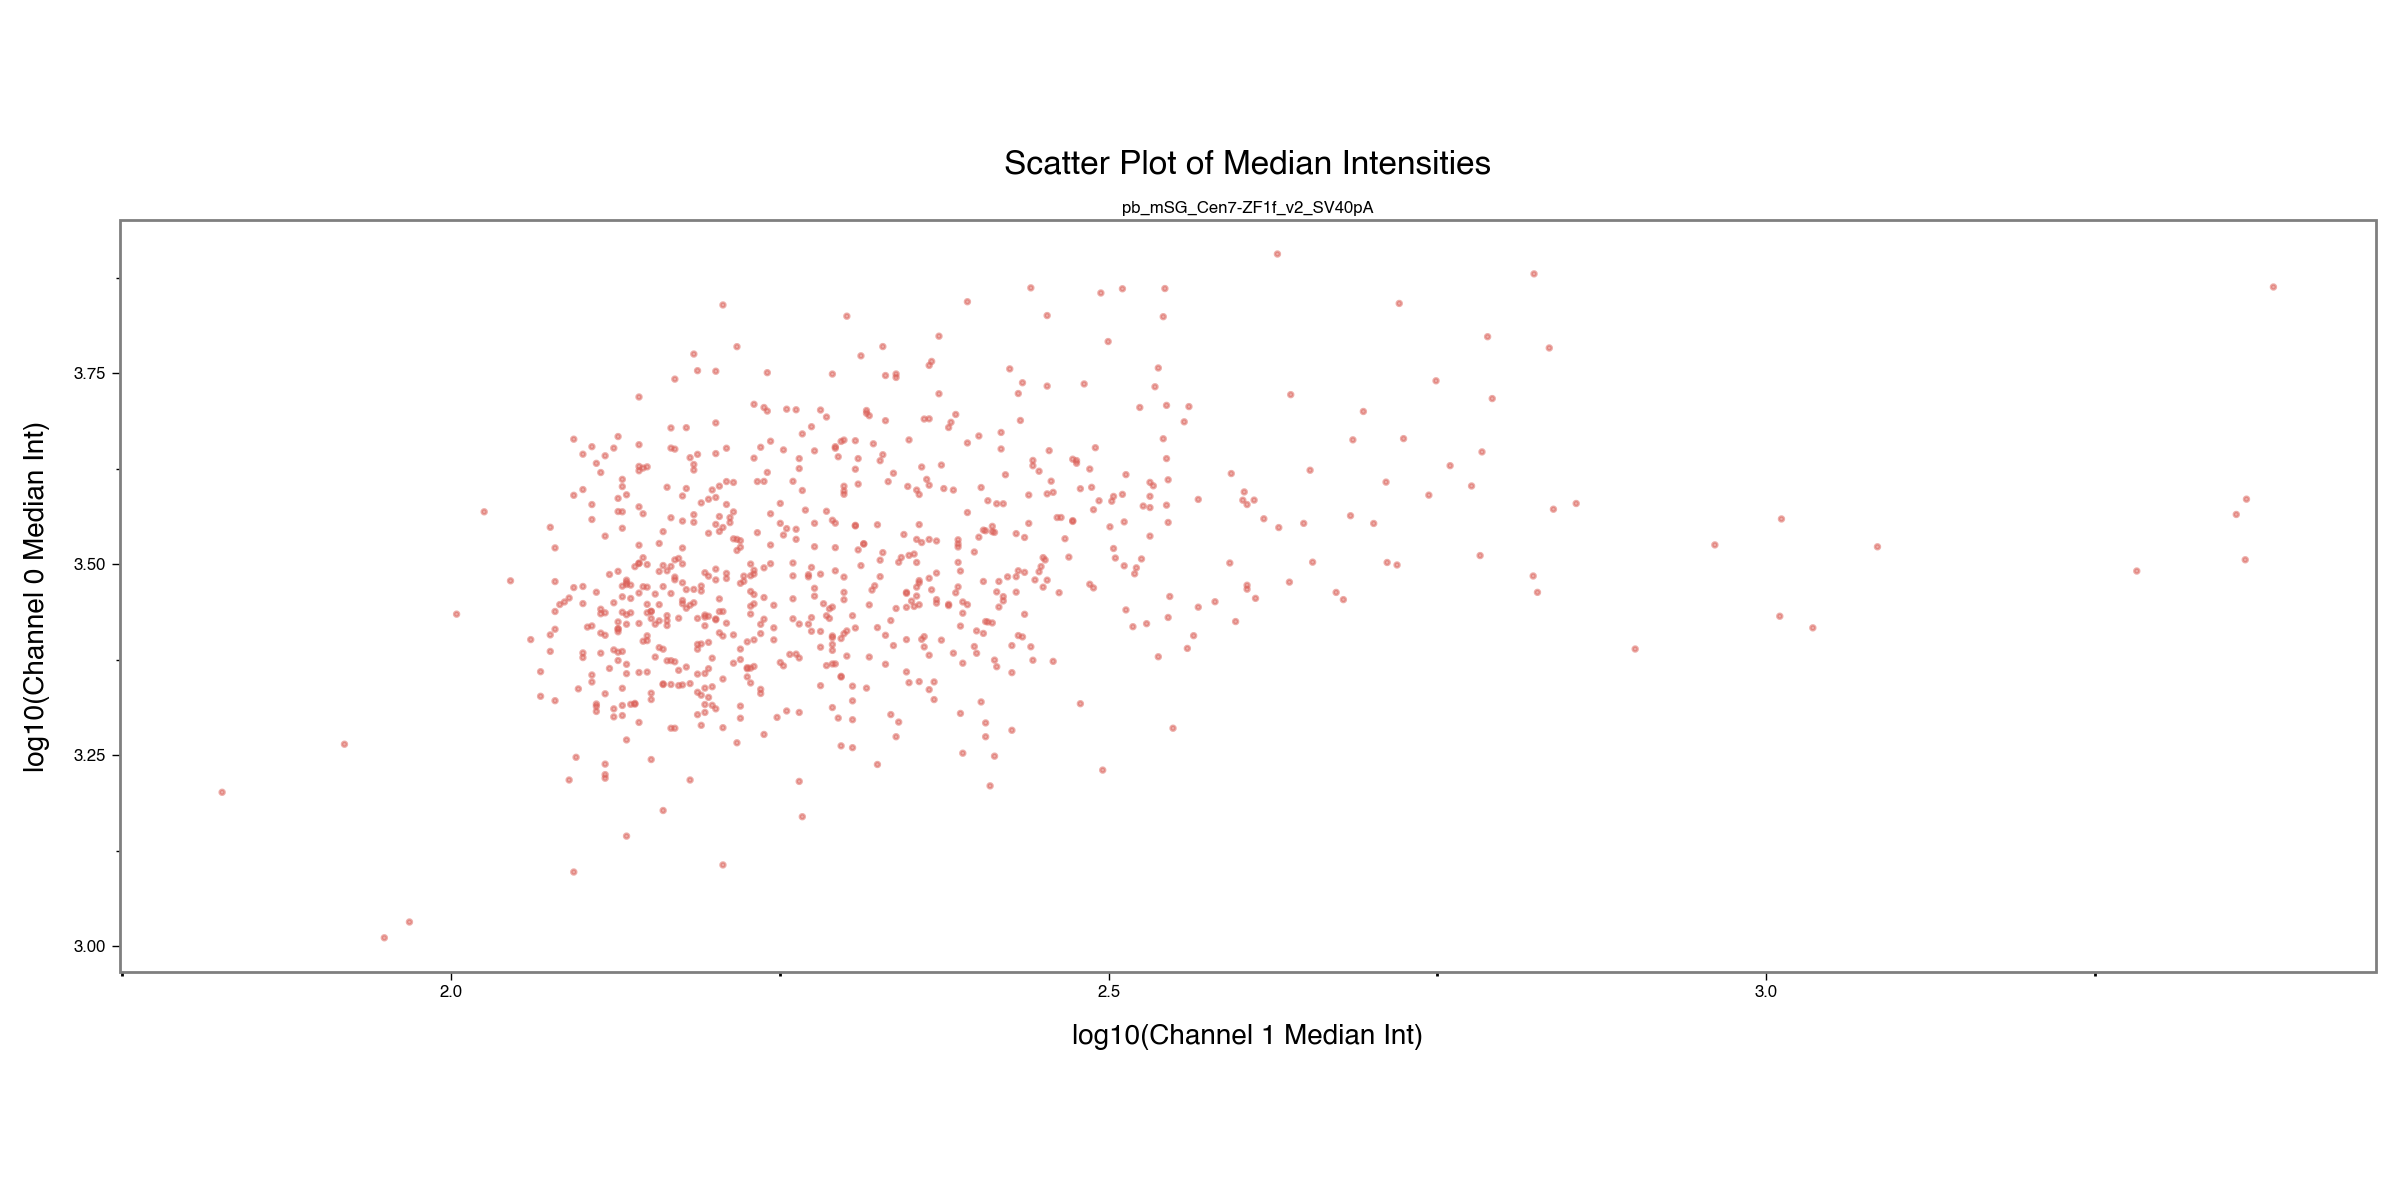

In [29]:
# Make an exploratory scatterplot of channel 1 vs channel 0 data
# to assess trends that may need correcting
plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'ch1_log10_median', 
                               y = 'ch0_log10_median', 
                              color = 'experiment')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 1 Median Int)',
        y = 'log10(Channel 0 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1/3,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill = 'white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

There seems to be some sort of relationship between Channel 1 and Channel 0 that should not be there. 
I will fit a linear model to the data of untransfected cells, and use the slope to correct the values of channel 1 (GFP) in all groups

In [30]:
# CHUNK 8
# Correct Channel 1 values

import statsmodels.api as sm

# Define which channels to correct (against ch0, Hoechst)
channels_to_correct = [1, 2, 3]  # <-- User defines this list

# Initialize new columns for corrected values
for ch in channels_to_correct:
    wide_df[f'cor_ch{ch}_log10_median'] = np.nan

# Loop through each experiment
for experiment in wide_df['experiment'].unique():
    # Filter data for the current experiment and make a copy to avoid SettingWithCopyWarning
    exp_data = wide_df[wide_df['experiment'] == experiment].copy()

    # Filter for untransfected cells (control group)
    utx = exp_data[exp_data['plasmid'] == 'none']
    #utx = exp_data[(exp_data['plasmid'] == 'none') & (exp_data['genotype'] == 'D29')]

    # Prepare the independent variable (ch0) — same for all channels
    X = sm.add_constant(utx['ch0_log10_median'])

    # Loop through each channel to correct
    for ch in channels_to_correct:
        ch_col = f'ch{ch}_log10_median'
        cor_col = f'cor_ch{ch}_log10_median'

        if ch_col not in exp_data.columns:
            print(f"  Skipping ch{ch} — column '{ch_col}' not found.")
            continue
        
        # Fit OLS model using untransfected cells
        y = utx[ch_col]
        model = sm.OLS(y, X).fit()
        
        beta = model.params['ch0_log10_median']
        intercept = model.params['const']
        
        print(f"Experiment: {experiment} | Channel: {ch}")
        print(f"  Slope (beta): {beta:.4f} | Intercept: {intercept:.4f}")
        
        # Store original range
        or_min = exp_data[ch_col].min()
        or_max = exp_data[ch_col].max()
        
        # Apply correction: subtract the ch0-dependent component
        corrected = exp_data[ch_col] - (beta * exp_data['ch0_log10_median'])
        
        # Rescale to original range
        cor_min, cor_max = corrected.min(), corrected.max()
        exp_data[cor_col] = (corrected - cor_min) / (cor_max - cor_min) * (or_max - or_min) + or_min
        
        # Write back to wide_df
        wide_df.loc[wide_df['experiment'] == experiment, cor_col] = exp_data[cor_col]

ValueError: zero-size array to reduction operation maximum which has no identity

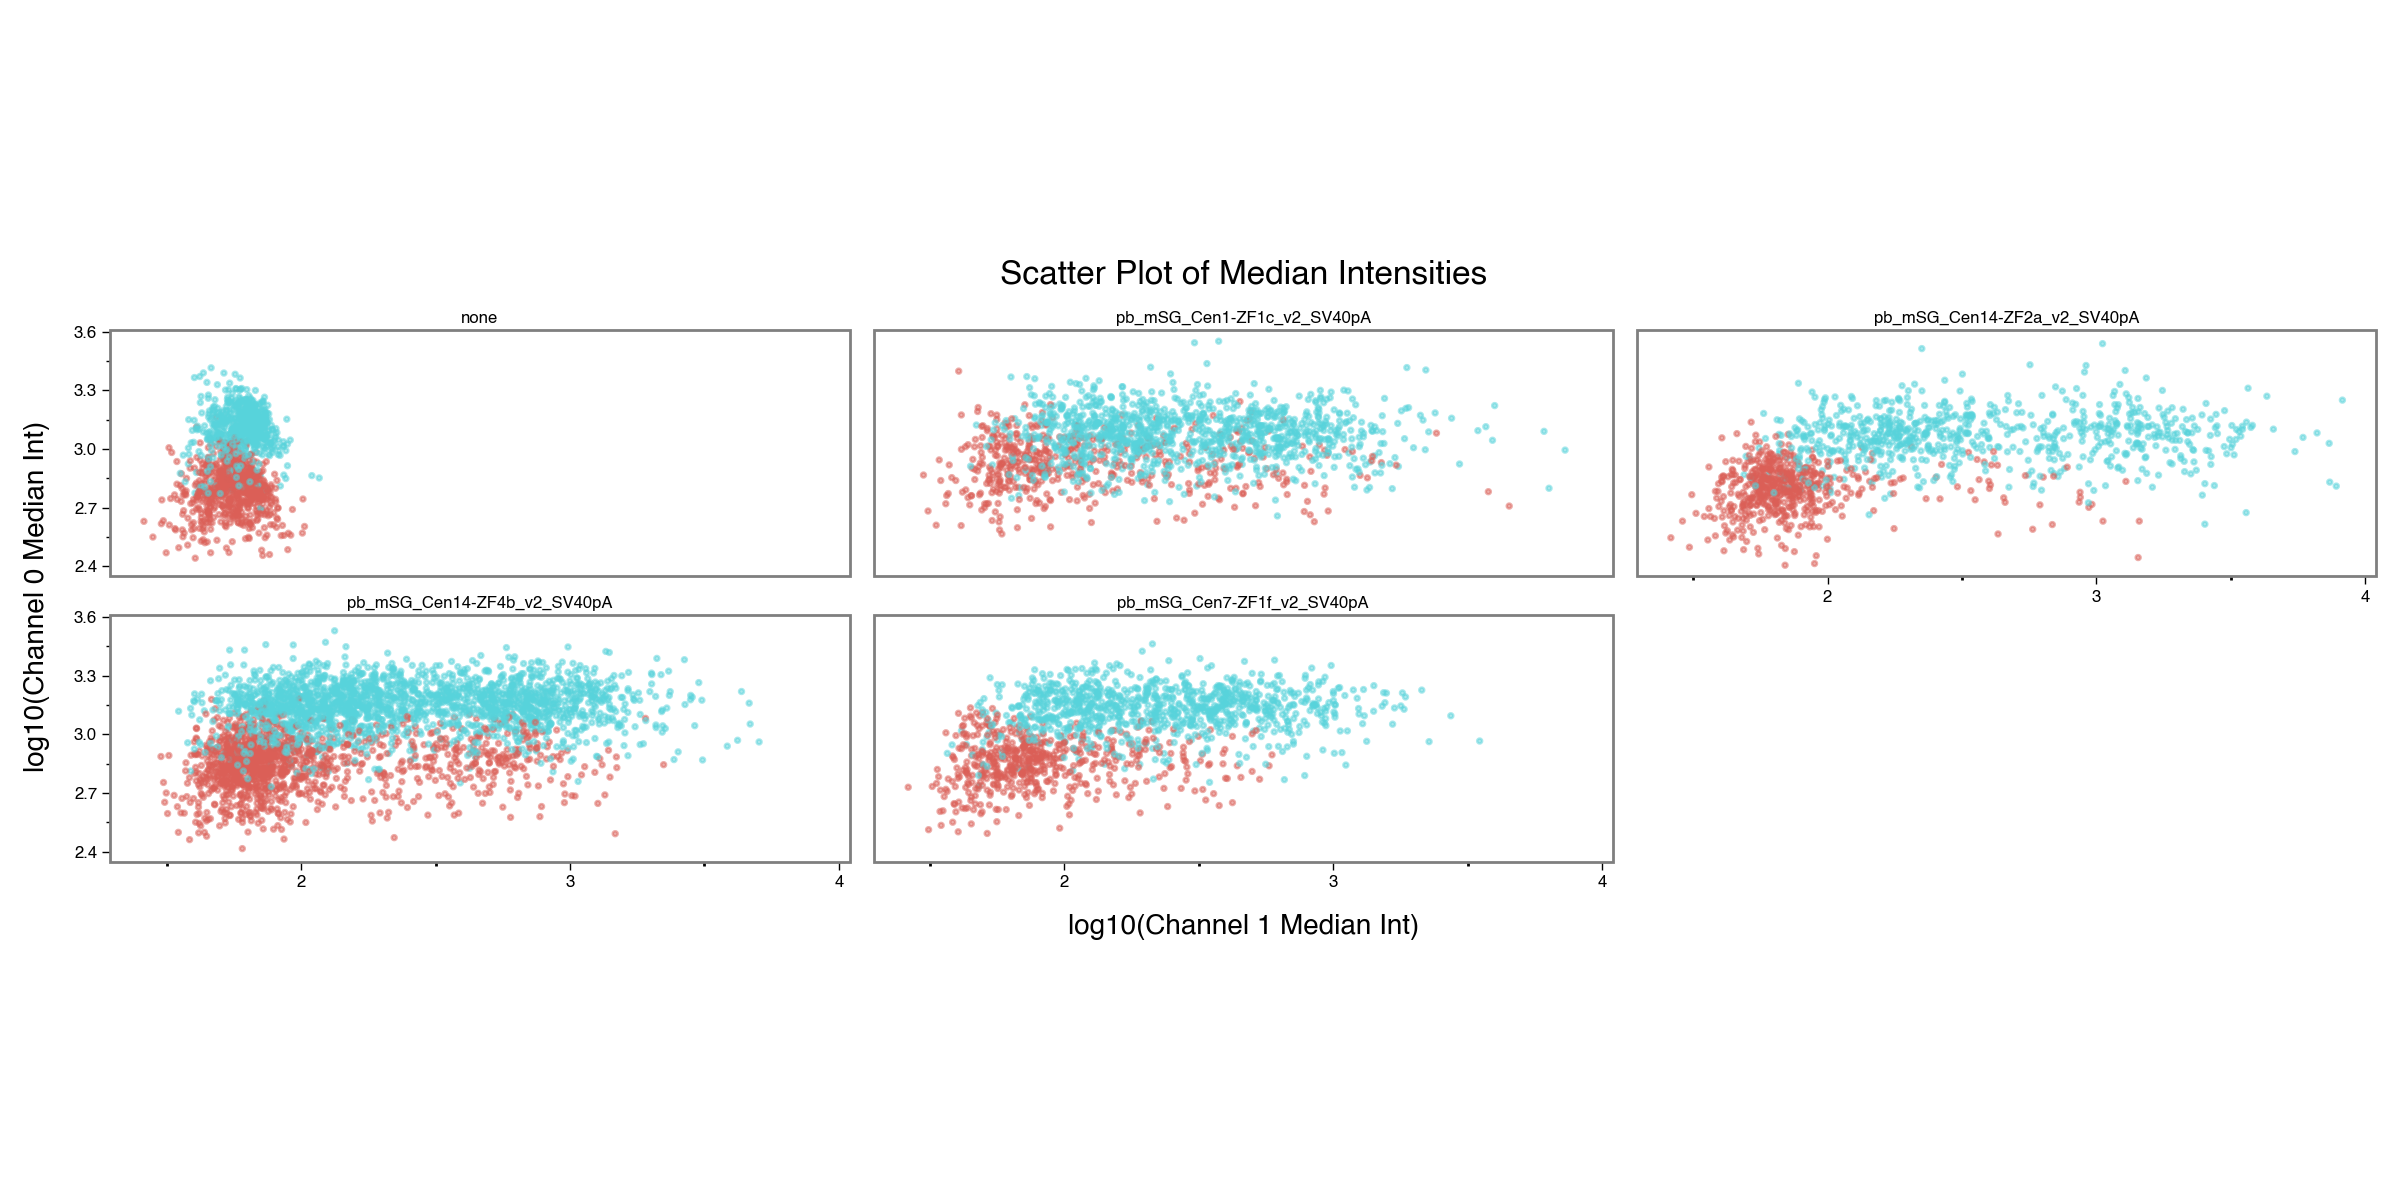

In [102]:
# Make the same scatterplot as above, using the corrected data
plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'cor_ch1_log10_median', 
                               y = 'ch0_log10_median', 
                              color = "experiment")) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 1 Median Int)',
        y = 'log10(Channel 0 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1/3,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/themes/themeable.py:2438: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


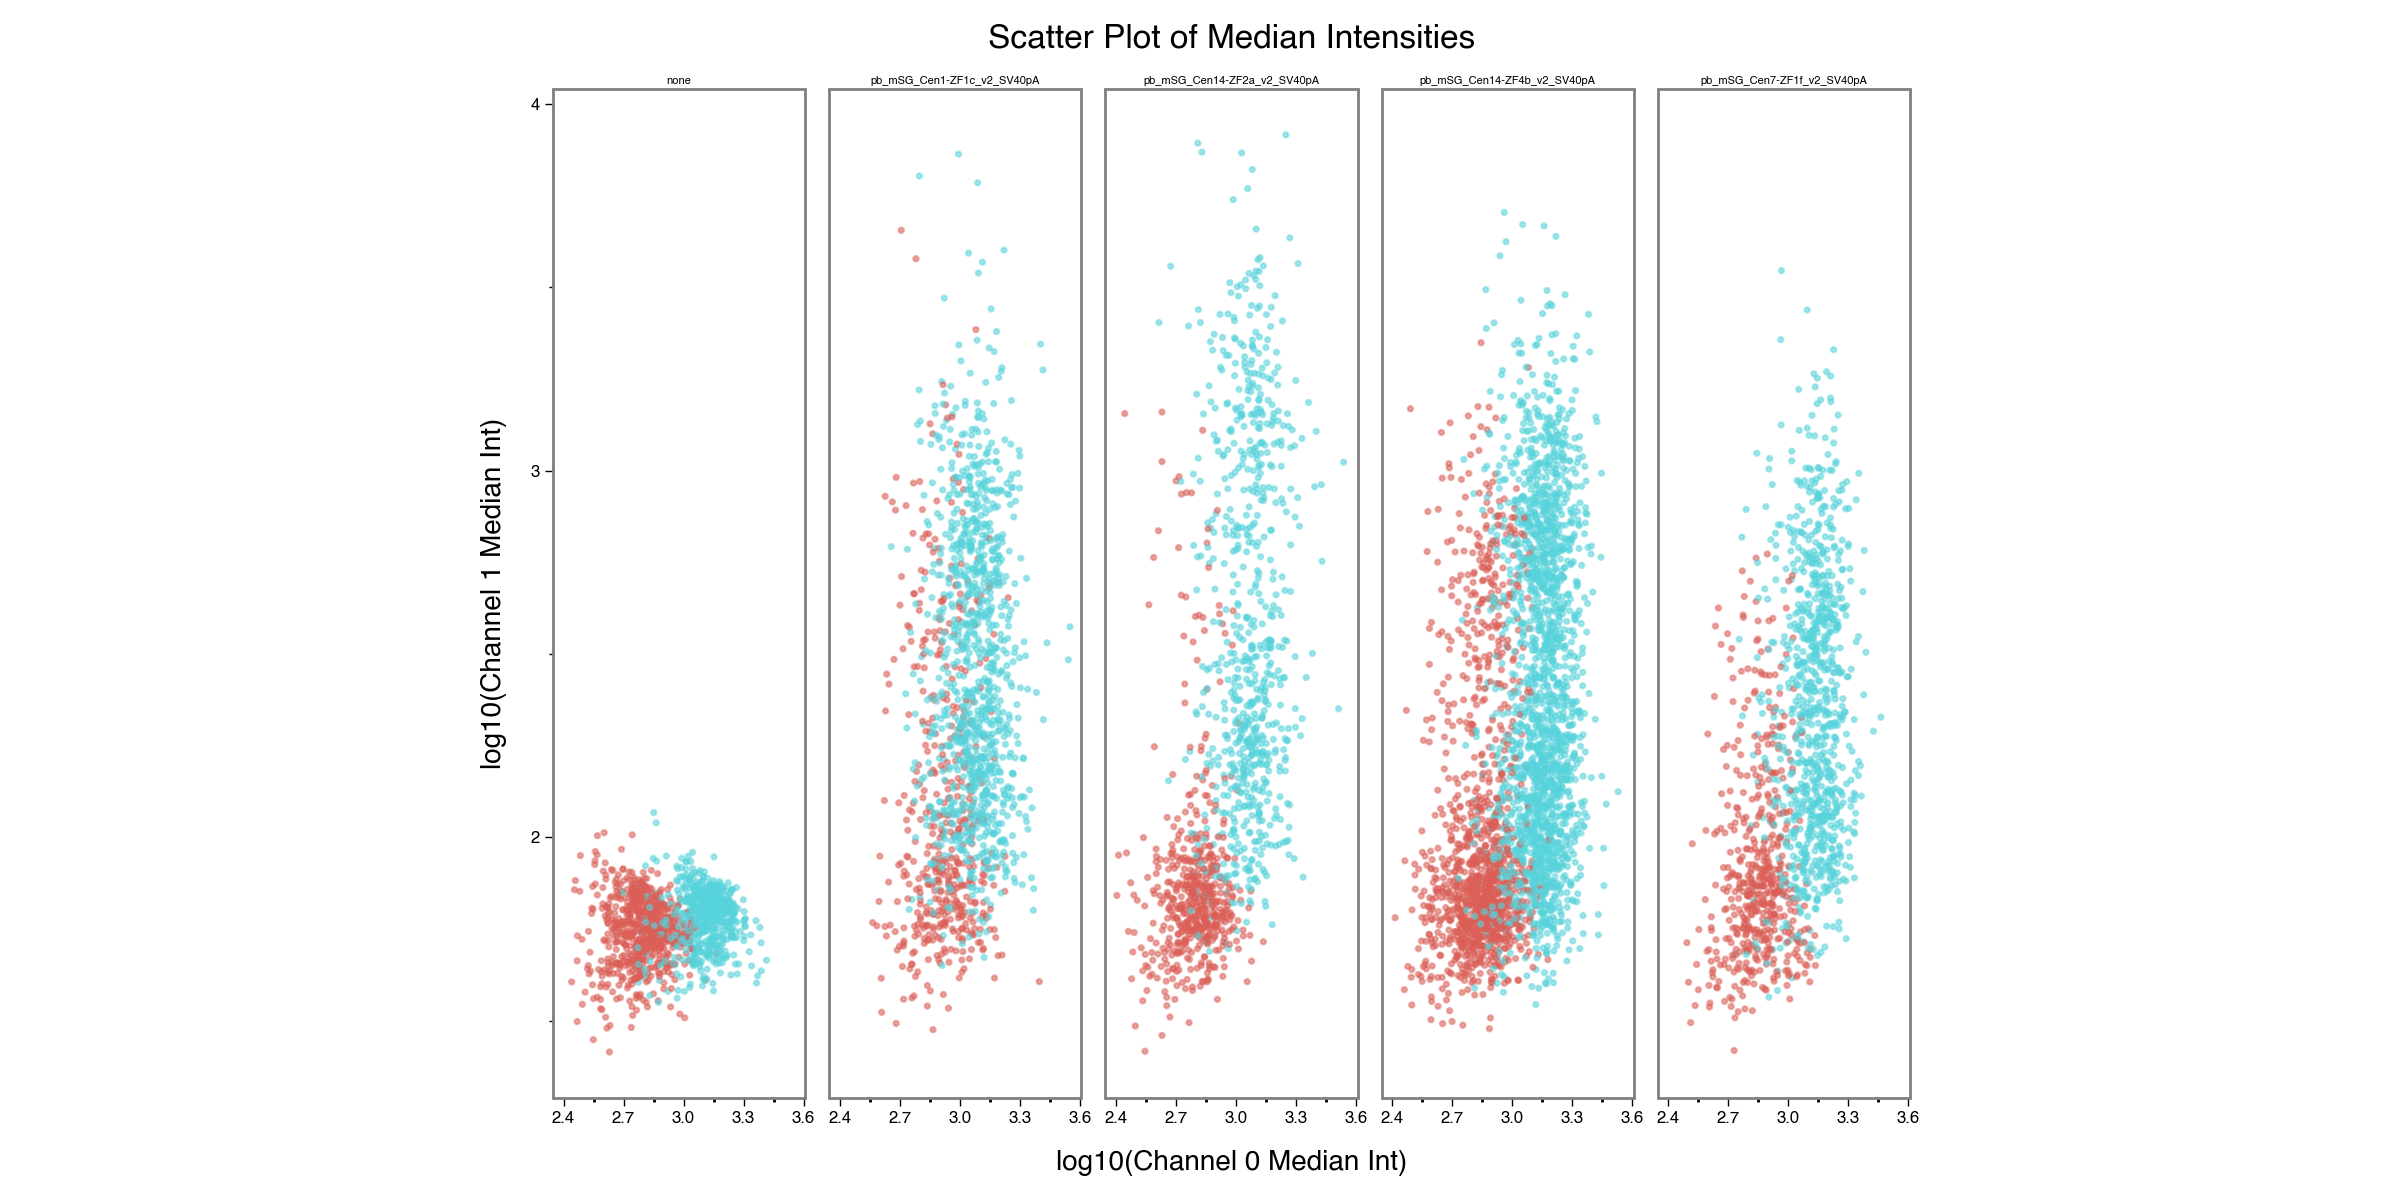

In [55]:
# Make the same scatterplot as above, using the corrected data
# with Hoechst in X axis, GFP in Y axis, separating by experiment

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(y = 'cor_ch1_log10_median', 
                               x = 'ch0_log10_median', 
                              color = "experiment")) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 0 Median Int)',
        y = 'log10(Channel 1 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid', nrow = 1) +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 4,
        subplots_adjust = {'wspace': 0.10},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 4, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

In [ ]:
print(wide_df.head())

In [103]:
# Classify cells according to GFP expression using thresholding

# Define which channels to classify
channels_to_classify = [1, 2, 3]  # <-- User defines this list

# Default hard thresholds — one per channel (used if no 'none' reference group exists)
default_thresholds = {
    1: 2.65,
    2: 2.30,
    3: 2.40,
}

# SD multiplier as cutoff for thresholding (default: 3)
sdcutoff = 3

def apply_threshold(group, thresholds=None, channels=channels_to_classify):
    """
    Classify cells as 'labeled'/'unlabeled' for each channel in `channels`.

    Parameters
    ----------
    group : DataFrame
        A per-experiment subset of wide_df.
    thresholds : dict or None
        Optional manual thresholds, e.g. {1: 3.0, 2: 2.8, 3: 2.5}.
        If None, thresholds are computed from the 'none' reference group (untransfected or unstained).
        Channels absent from the dict fall back to the auto/default logic.
    channels : list
        Channels to classify. Defaults to the global channels_to_classify.
    """
    # Identify the untransfected reference group once
    utx_df = group[group['plasmid'] == 'none']
    has_reference = len(utx_df) > 0

    for ch in channels:
        cor_col = f'cor_ch{ch}_log10_median'
        class_col = f'class_thr_ch{ch}'

        if cor_col not in group.columns:
            print(f"  Skipping ch{ch} — column '{cor_col}' not found.")
            continue

        # Determine threshold for this channel
        if thresholds is not None and ch in thresholds:
            # Manual threshold supplied for this channel
            threshold = thresholds[ch]
        elif has_reference:
            # Auto threshold from reference group
            threshold = (np.median(utx_df[cor_col])
                         + sdcutoff * np.std(utx_df[cor_col]))
        else:
            # Fall back to hard-coded default
            threshold = default_thresholds.get(ch)
            if threshold is None:
                print(f"  No threshold available for ch{ch} — skipping.")
                continue
            print(f"  No reference group found for ch{ch}; "
                  f"using default threshold: {threshold}")

        group[class_col] = np.where(
            group[cor_col] > threshold, "labeled", "unlabeled"
        )

    return group

# --- Auto thresholds (reference group-derived) ---
wide_df = (wide_df
           .groupby('experiment', group_keys=False)
           .apply(apply_threshold)
           .reset_index(drop=True))

# --- Manual thresholds (all channels) ---
# custom_thresholds = {1: 3.0, 2: 2.8, 3: 2.5}
# wide_df = (wide_df
#            .groupby('experiment', group_keys=False)
#            .apply(apply_threshold, thresholds=custom_thresholds)
#            .reset_index(drop=True))

# --- Mixed: manual for ch1, auto for ch2 and ch3 ---
# custom_thresholds = {1: 3.0}
# wide_df = (wide_df
#            .groupby('experiment', group_keys=False)
#            .apply(apply_threshold, thresholds=custom_thresholds)
#            .reset_index(drop=True))

/var/folders/ms/knsq1kqj0cbgqnbmt1rng0yw0000gr/T/ipykernel_31046/3411161313.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [ ]:
print(wide_df.head())

In [131]:
# Classify cells using a Bayesan Gaussian Mixture Model, instead of the GMM above
# This is more robust when dealing with groups of unequal size
# It gives all cells with plasmid == "none" (untransfected, wt, etc) the "unlabeled" value, 
# and only classifies the rest

from sklearn.mixture import BayesianGaussianMixture

def apply_bgmm(group, channels=channels_to_classify):
    group = group.copy()
    expt_name = group['experiment'].iloc[0]
    plasmid_name = group['plasmid'].iloc[0]
    is_control = (plasmid_name == 'none')
    group_label = f"experiment={expt_name} | plasmid={plasmid_name}"

    for ch in channels:
        col = f'cor_ch{ch}_log10_median'
        cluster_col = f'cluster_ch{ch}'
        class_col = f'class_gmm_ch{ch}'

        group[cluster_col] = np.nan
        group[class_col] = "failed_gmm"

        if col not in group.columns:
            print(f"[BGMM INFO] {group_label} | ch{ch}: column '{col}' not found — skipping.")
            continue

        finite_mask = group[col].notna() & np.isfinite(group[col])
        n_total, n_valid = len(group), finite_mask.sum()
        n_dropped = n_total - n_valid

        print(f"[BGMM INFO] {group_label} | ch{ch} | "
              f"total_cells={n_total} | valid={n_valid} | dropped={n_dropped}")

        if n_valid < 2:
            print(f"[BGMM WARNING] {group_label} | ch{ch}: only {n_valid} usable cells — skipping.")
            continue

        clean_data = group.loc[finite_mask, col].to_numpy().reshape(-1, 1)

        # Control groups are always classified as unlabeled — no need to fit a GMM
        if is_control:
            print(f"[BGMM INFO] {group_label} | ch{ch}: "
                  f"control group — classifying all cells as 'unlabeled'.")
            group.loc[finite_mask, class_col] = "unlabeled"
            continue

        try:
            bgmm = BayesianGaussianMixture(
                n_components=2,
                n_init=5,
                random_state=0,
                weight_concentration_prior_type='dirichlet_distribution',
                weight_concentration_prior=0.15,
                covariance_type='tied',  # Both components share the same covariance matrix
            )
            bgmm.fit(clean_data)

            effective_components = np.sum(bgmm.weights_ > 0.05)
            print(f"[BGMM INFO] {group_label} | ch{ch}: "
                  f"effective components={effective_components} | "
                  f"weights={np.round(bgmm.weights_, 3)}")

            cluster_labels = bgmm.predict(clean_data)
            group.loc[finite_mask, cluster_col] = cluster_labels

            if effective_components == 1:
                dominant_mean = bgmm.means_.flatten()[np.argmax(bgmm.weights_)]
                overall_median = np.median(clean_data)
                single_class = "labeled" if dominant_mean > overall_median else "unlabeled"
                print(f"[BGMM INFO] {group_label} | ch{ch}: "
                      f"single effective component — classifying all as '{single_class}'.")
                group.loc[finite_mask, class_col] = single_class
            else:
                means = bgmm.means_.flatten()
                negative_lbl = 0 if means[0] < means[1] else 1
                group.loc[finite_mask, class_col] = np.where(
                    group.loc[finite_mask, cluster_col] == negative_lbl,
                    "unlabeled", "labeled"
                )

        except ValueError as e:
            print(f"[BGMM ERROR] {group_label} | ch{ch}: BGMM failed to fit: {e}")

    return group

# Apply BGMM clustering grouped by experiment AND plasmid
wide_df = (wide_df
           .groupby(['experiment', 'plasmid'], group_keys=False)
           .apply(apply_bgmm)
           .reset_index(drop=True))

[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=none | ch1 | total_cells=702 | valid=702 | dropped=0
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=none | ch1: control group — classifying all cells as 'unlabeled'.
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=none | ch2 | total_cells=702 | valid=702 | dropped=0
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=none | ch2: control group — classifying all cells as 'unlabeled'.
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=none | ch3 | total_cells=702 | valid=702 | dropped=0
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=none | ch3: control group — classifying all cells as 'unlabeled'.
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=pb_mSG_Cen1-ZF1c_v2_SV40pA | ch1 | total_cells=487 | valid=487 | dropped=0
[BGMM INFO] experiment=03062026_ZF-multicolor | plasmid=pb_mSG_Cen1-ZF1c_v2_SV40pA | ch1: effective components=2 | weights=[0.759 0.241]
[BGMM INFO] experiment=03062026_ZF-mult

/var/folders/ms/knsq1kqj0cbgqnbmt1rng0yw0000gr/T/ipykernel_31046/4031369224.py:89: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


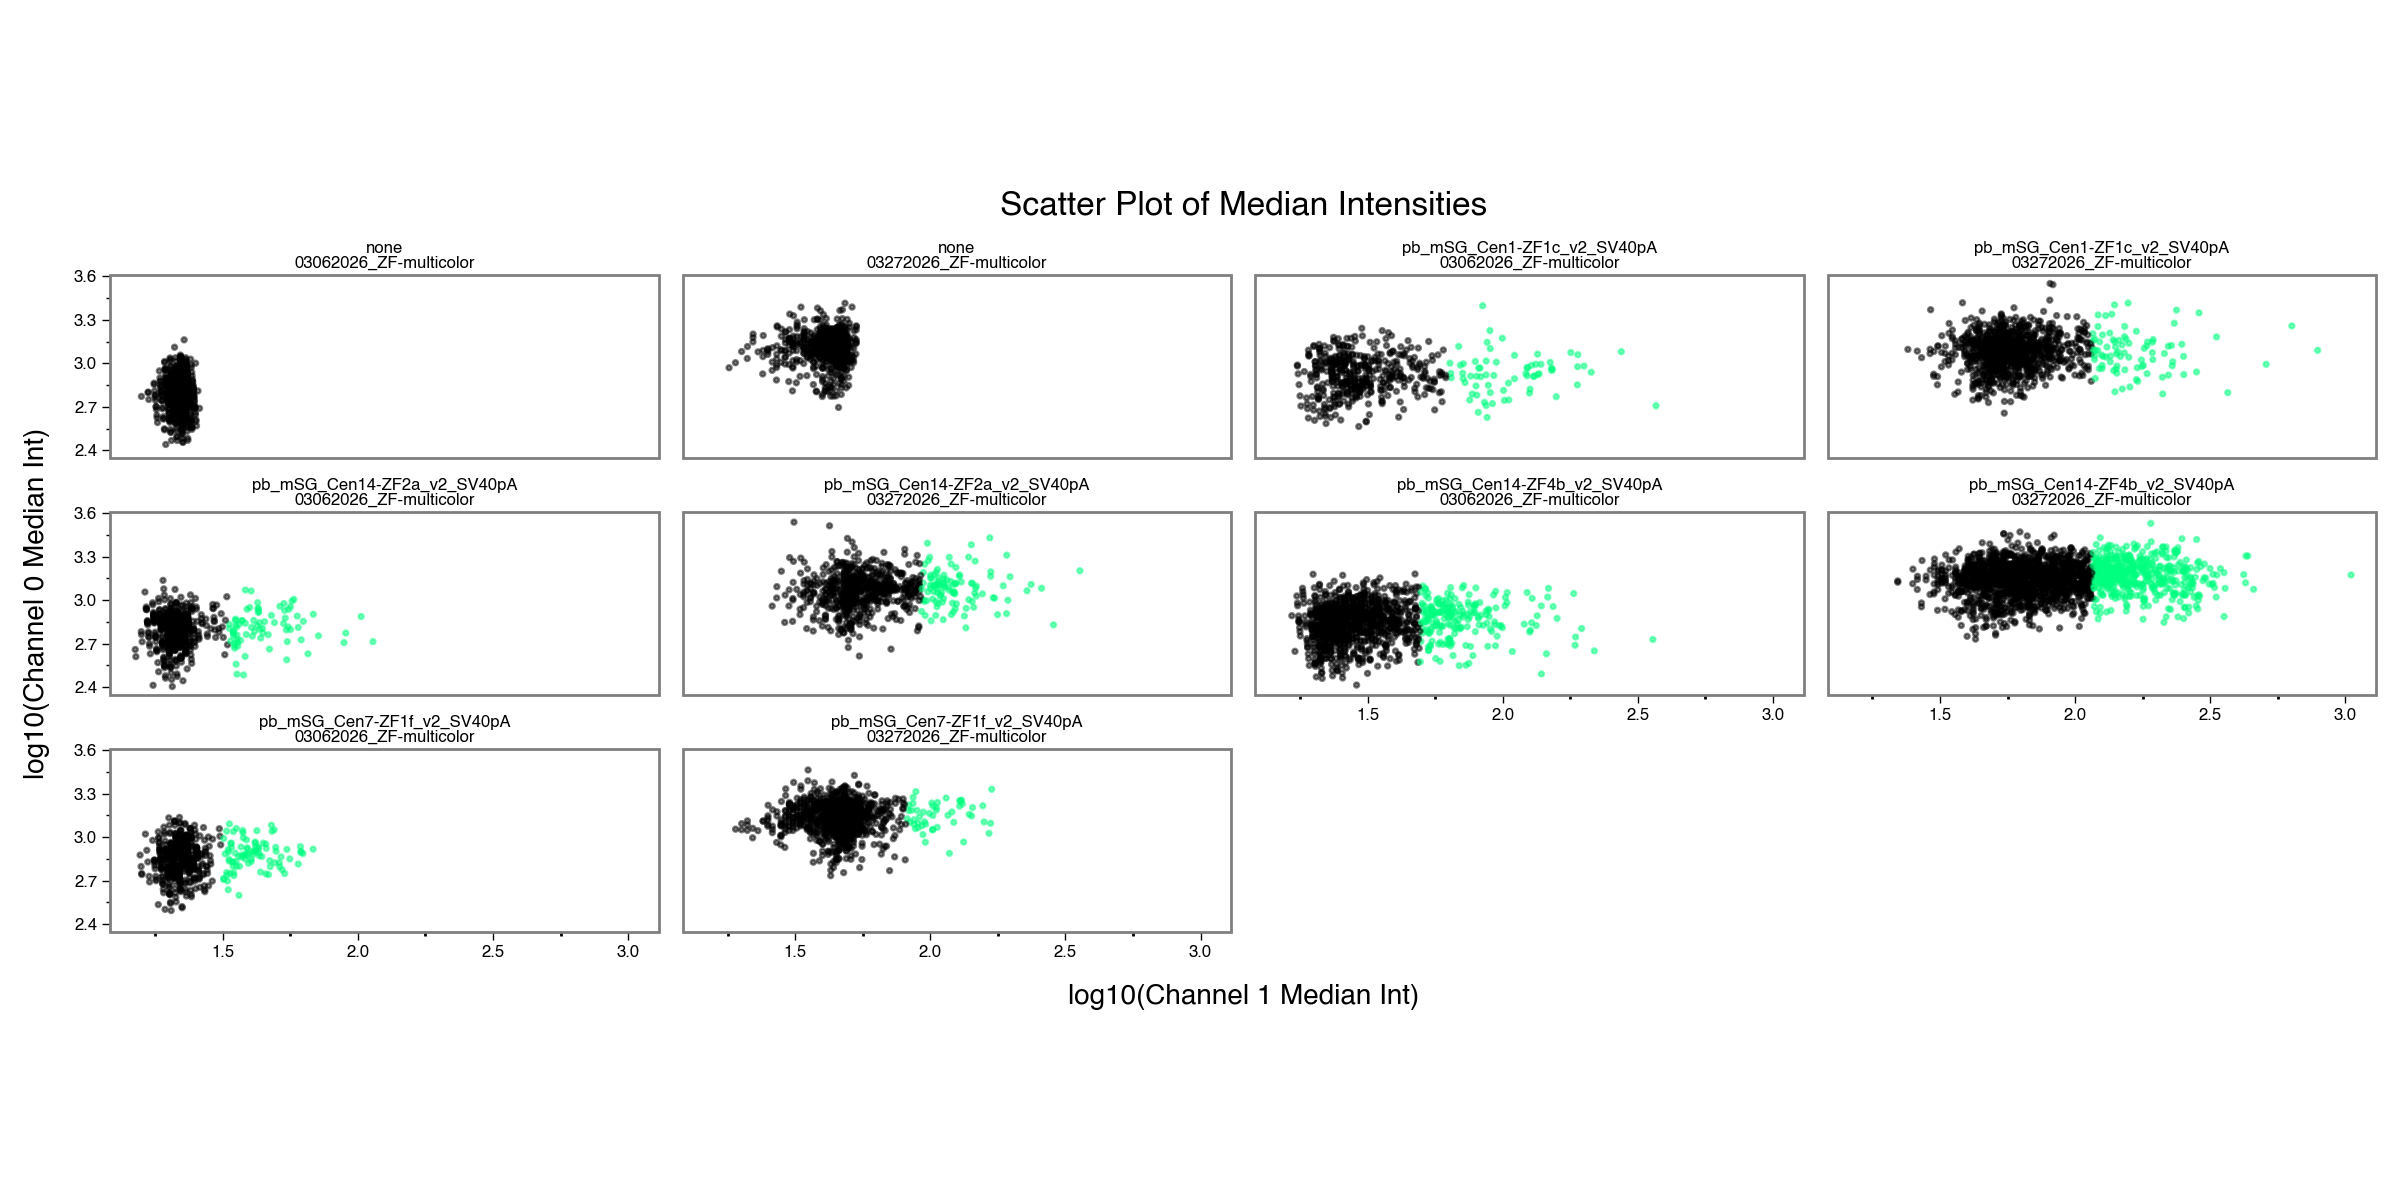

In [132]:
# Visualize the result of the classification we just did
# as a scatterplot

# Determine the classification method to plot the results for
# "class_gmm" or "class_thr"
class_method = "class_gmm_ch2"

groupcols = {"labeled": 'springgreen', "unlabeled": 'black'}

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'cor_ch2_log10_median', 
                               y = 'ch0_log10_median', 
                              color = class_method)) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, alpha = 0.5) +  # Add points for scatter plot
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log10(Channel 1 Median Int)', 
        y = 'log10(Channel 0 Median Int)'
    ) + 
    p9.scale_color_manual(values = groupcols) + 
    p9.facet_wrap(' ~ plasmid + experiment') +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (12, 6),  # Set the size of the plot
        aspect_ratio = 1/3,
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
plot

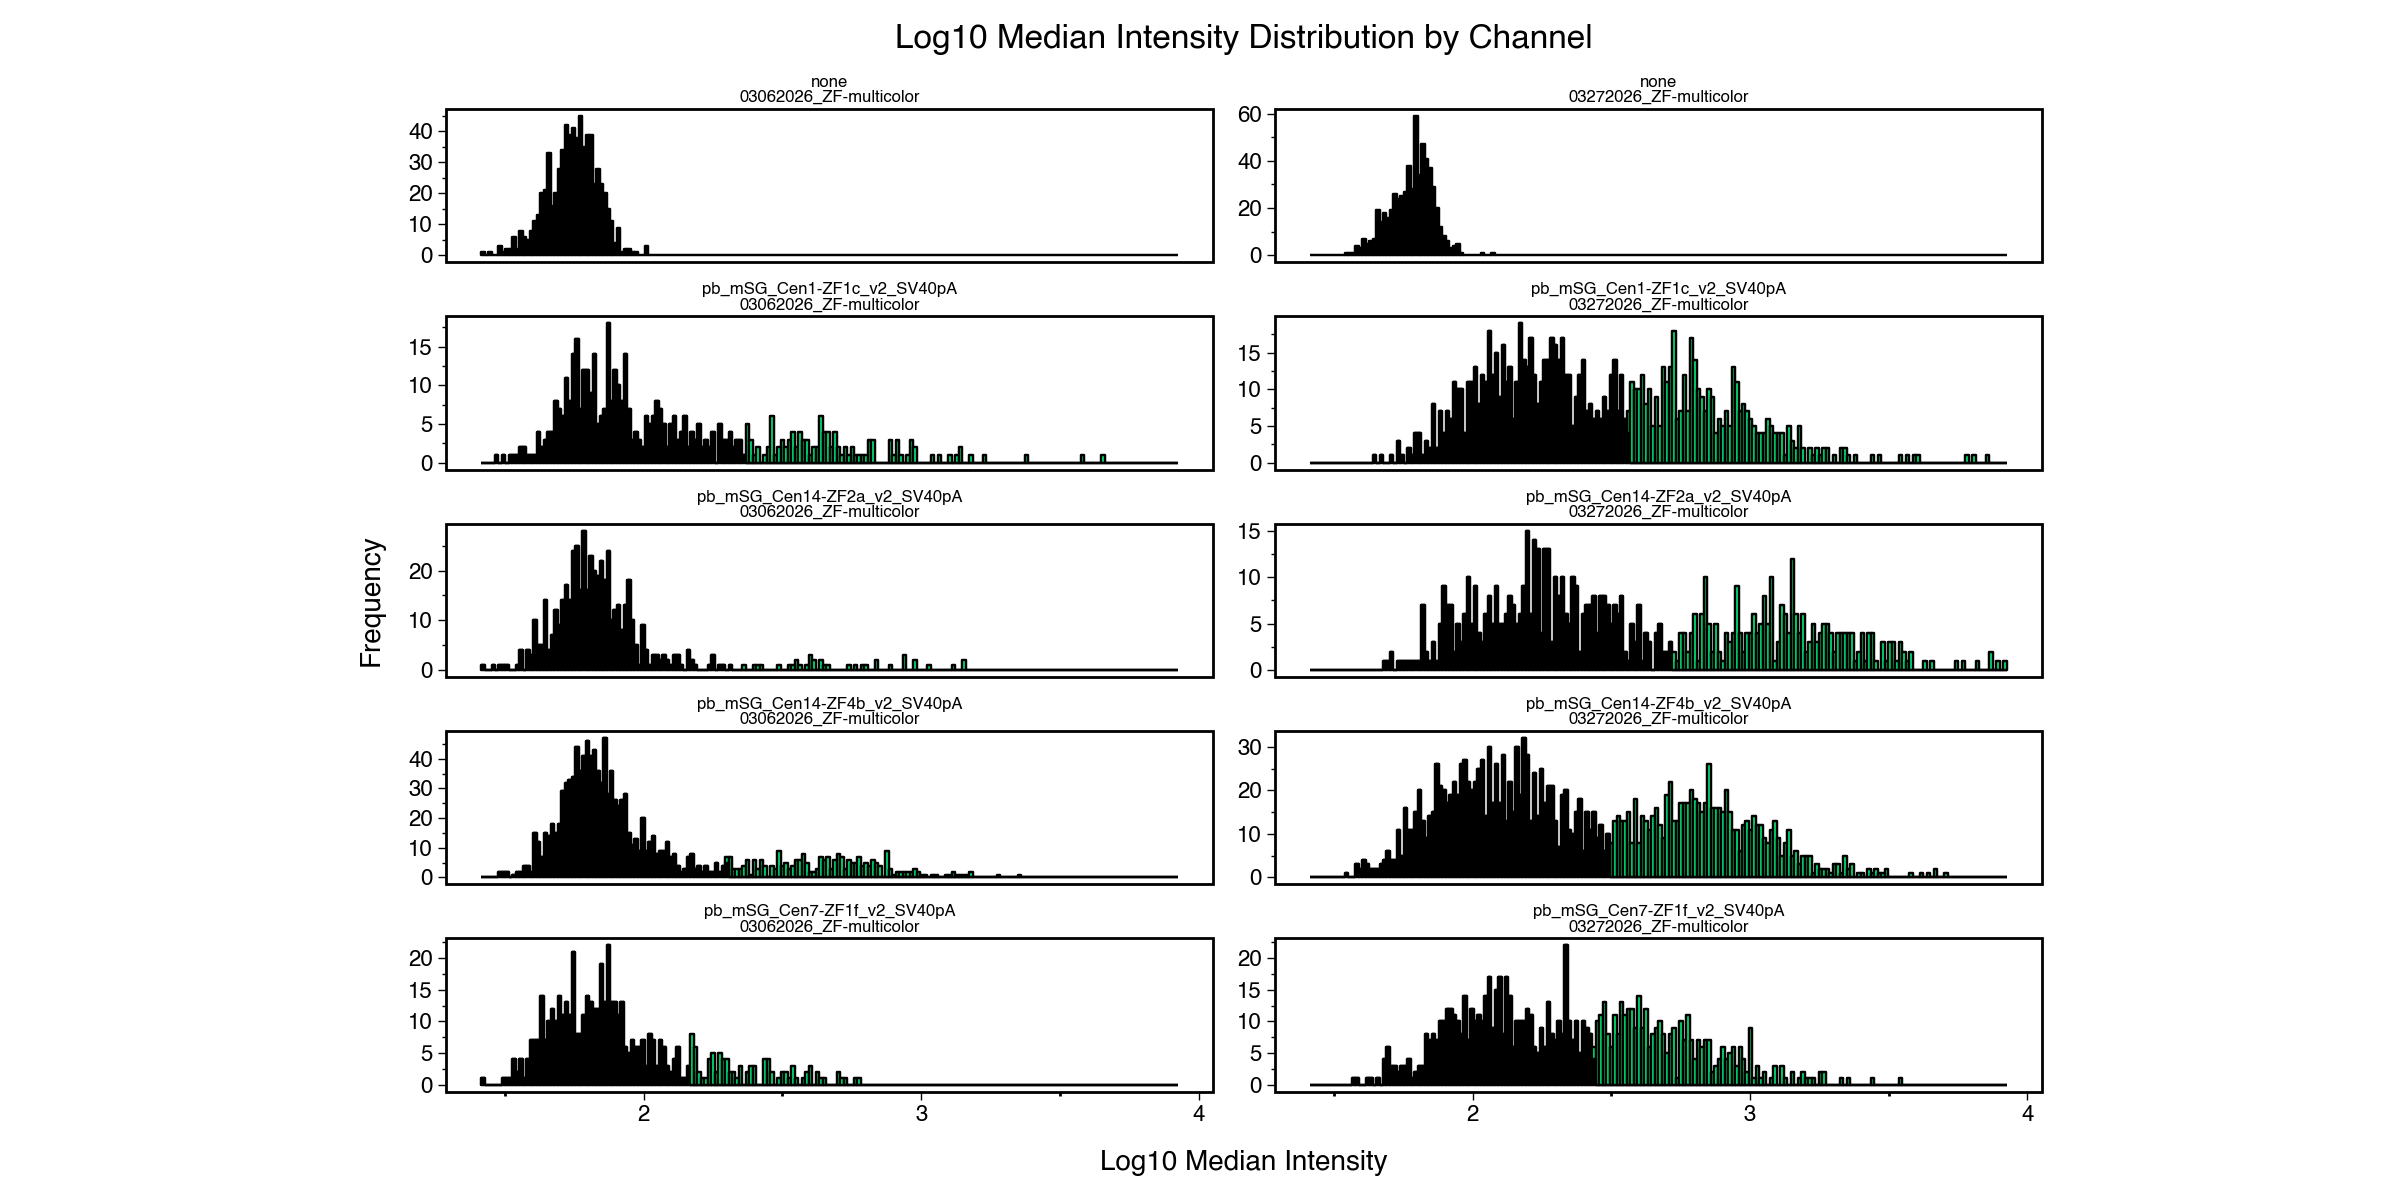

In [127]:
# Visualize the result of the classification we just did
# as a histogram

# Determine the classification method to plot the results for
# "class_gmm_chN" or "class_thr_chN"
class_method = "class_gmm_ch1"

plot = (
    p9.ggplot(data = wide_df) + 
    p9.aes(x = 'cor_ch1_log10_median', fill = class_method) +  # factor() to treat channel as categorical
    p9.geom_histogram(bins = 200, color = 'black') +
    p9.facet_wrap(' ~ plasmid + experiment', scales = 'free_y', ncol = 2) +  # Create separate plots for each channel
    #p9.scale_x_continuous(limits = (combined_df['log10_median'].min(), 
    #                                combined_df['log10_median'].max())) +
    p9.scale_fill_manual(values = groupcols) +
    p9.labs(title = 'Log10 Median Intensity Distribution by Channel',
            x = 'Log10 Median Intensity',
            y = 'Frequency') +
    p9.theme_bw() + 
    p9.theme(figure_size = (12, 6), # Adjust figure size
             aspect_ratio = 1/5,
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 6, color = 'black'))
)

# Print the plot
plot

In [118]:
wide_df.columns.tolist()

['image_index',
 'base_name',
 'experiment',
 'plasmid',
 'plasmid2',
 'plasmid3',
 'promoter',
 'fusion',
 'probe',
 'ROI_index',
 'ch0_log10_median',
 'ch1_log10_median',
 'ch2_log10_median',
 'ch3_log10_median',
 'cor_ch1_log10_median',
 'cor_ch2_log10_median',
 'cor_ch3_log10_median',
 'class_thr_ch1',
 'class_thr_ch2',
 'class_thr_ch3',
 'class_gmm_ch1',
 'class_gmm_ch2',
 'class_gmm_ch3']

In [133]:
# Lastly, re-shape the data frame back to long format
# ----------
# -- This is a new addition, so old data sets have not undergone this transformation,
# -- be careful in downstream steps

# Columns to keep as-is (everything that isn't channel-specific)
id_cols = ['experiment', 'base_name', 'image_index', 'plasmid', 
           'plasmid2', 'plasmid3', 
           'promoter', 'fusion', 'probe', 
           'ROI_index']

# Drop cluster columns
cluster_cols = [f'cluster_ch{ch}' for ch in channels_to_classify]
wide_df = wide_df.drop(columns = cluster_cols, errors = 'ignore')

# Melt each family of channel columns separately, then merge
def melt_channel_var(df, var_prefix, var_suffix, value_name, channels, id_cols):
    """Extract one family of channel columns into long format."""
    cols = [f'{var_prefix}{ch}{var_suffix}' for ch in channels]
    cols = [c for c in cols if c in df.columns]
    return (df[id_cols + cols]
            .melt(id_vars=id_cols,
                  value_vars=cols,
                  var_name='channel',
                  value_name=value_name)
            .assign(channel=lambda x: x['channel']
                    .str.extract(r'ch(\d+)')[0]
                    .astype(int)))

# Then all four calls are consistent and readable:
long_raw       = melt_channel_var(wide_df, 'ch', '_log10_median', 
                                   'log10_median', channels_to_classify, id_cols)
long_intensity = melt_channel_var(wide_df, 'cor_ch', '_log10_median', 
                                   'cor_log10_median', channels_to_classify, id_cols)
long_thr       = melt_channel_var(wide_df, 'class_thr_ch', '', 
                                   'class_thr', channels_to_classify, id_cols)
long_gmm       = melt_channel_var(wide_df, 'class_gmm_ch', '', 
                                   'class_gmm', channels_to_classify, id_cols)

# Merge all four
long_df = (long_raw
           .merge(long_intensity, on=id_cols + ['channel'])
           .merge(long_thr,       on=id_cols + ['channel'])
           .merge(long_gmm,       on=id_cols + ['channel']))

long_df = long_df[id_cols + ['channel', 'log10_median', 'cor_log10_median', 
                              'class_thr', 'class_gmm']]

print(long_df.shape)
print(long_df.head())

(26025, 15)
               experiment                                      base_name  \
0  03272026_ZF-multicolor  03272026_multicolor_group2_1_MMStack_Pos4_MIP   
1  03272026_ZF-multicolor  03272026_multicolor_group2_1_MMStack_Pos4_MIP   
2  03272026_ZF-multicolor  03272026_multicolor_group2_1_MMStack_Pos4_MIP   
3  03272026_ZF-multicolor  03272026_multicolor_group2_1_MMStack_Pos4_MIP   
4  03272026_ZF-multicolor  03272026_multicolor_group2_1_MMStack_Pos4_MIP   

   image_index                      plasmid  \
0            0  pb_mSG_Cen14-ZF4b_v2_SV40pA   
1            0  pb_mSG_Cen14-ZF4b_v2_SV40pA   
2            0  pb_mSG_Cen14-ZF4b_v2_SV40pA   
3            0  pb_mSG_Cen14-ZF4b_v2_SV40pA   
4            0  pb_mSG_Cen14-ZF4b_v2_SV40pA   

                              plasmid2                         plasmid3  \
0  pb_mScarlet3-H_Cen15-ZF2c_v2_sv40pA  pb_HaloTag_Cen22-ZF1a-v2_SV40pA   
1  pb_mScarlet3-H_Cen15-ZF2c_v2_sv40pA  pb_HaloTag_Cen22-ZF1a-v2_SV40pA   
2  pb_mScarlet3-H_Cen15

In [136]:
# FILE SAVING #

# Save the cell classification table to disc

# Files for each experiment will be saved in their own folder as .csv files
# This approach makes it easy to import them into other notebooks and combine them again if needed

# Select only a subset of variables to export:
subset_df = long_df[['experiment', 'base_name', 'image_index', 'plasmid', 'ROI_index', 'channel',
                     'log10_median', 'cor_log10_median', 'class_thr', 'class_gmm']]

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Get today's date string to use as a suffix if older versions of the file are present
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    # and create it if not already present
    experiment_folder = os.path.join(results_dir, experiment)
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the Data Frame for the current experiment 
    # (Assumes it includes an "experiment" column.)
    subset_df_exp = subset_df[subset_df['experiment'] == experiment]
    
    # Define the default file path for the CSV file
    cell_class_file = os.path.join(experiment_folder, "cell_class.csv")
    
    # If the raw (no BS) file already exists, add the date suffix to create a new filename
    if os.path.exists(cell_class_file):
        cell_class_file = os.path.join(experiment_folder, f"cell_class_{date_suffix}.csv")
    
    # Save the data frame to its CSV file
    subset_df_exp.to_csv(cell_class_file, index=False)